### **Features**

|Abbr|Meaning|
|---|---|
|**Gender**|Gender|
|**Age**|Age|
|**Height**|Height|
|**Weight**|Weight|
|**family_history_with_overweight**|Has a family member suffered or suffers from overweight?|
|**FAVC**|Do you eat high caloric food frequently?|
|**FCVC**|Do you usually eat vegetables in your meals?|
|**NCP**|How many main meals do you have daily?|
|**CAEC**|Do you eat any food between meals?|
|**SMOKE**|Do you smoke?|
|**CH2O**|How much water do you drink daily?|
|**SCC**|Do you monitor the calories you eat daily?|
|**FAF**|How often do you have physical activity?|
|**TUE**|How much time do you use technological devices such as cell phone, videogames, television, computer and others?|
|**CALC**|How often do you drink alcohol?|
|**MTRANS**|Which transportation do you usually use?|
|**NObeyesdad**|Obesity level|


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_csv('../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv')
df.columns = [col.strip() for col in df.columns]

print(f'Dataset shape: {df.shape}')
print(f'Duplicate rows: {df.duplicated().sum()}')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0] if (missing_values > 0).any() else pd.Series(dtype='int64'))

print('\nSummary statistics for numeric columns:')
display(df.describe().T)

print('\nSummary statistics for all columns:')
display(df.describe(include='all').T)


Dataset shape: (2111, 17)
Duplicate rows: 24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Data types:


,dtype
Gender,str
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,str
FAVC,str
FCVC,float64
NCP,float64
CAEC,str
SMOKE,str



Missing values:


Series([], dtype: int64)


Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00



Summary statistics for all columns:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2111.0,NaN,NaN,NaN,24.3126,6.345968,14.0,19.947192,22.77789,26.0,61.0
Height,2111.0,NaN,NaN,NaN,1.701677,0.093305,1.45,1.63,1.700499,1.768464,1.98
Weight,2111.0,NaN,NaN,NaN,86.586058,26.191172,39.0,65.473343,83.0,107.430682,173.0
family_history_with_overweight,2111,2,yes,1726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2111.0,NaN,NaN,NaN,2.419043,0.533927,1.0,2.0,2.385502,3.0,3.0
NCP,2111.0,NaN,NaN,NaN,2.685628,0.778039,1.0,2.658738,3.0,3.0,4.0
CAEC,2111,4,Sometimes,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


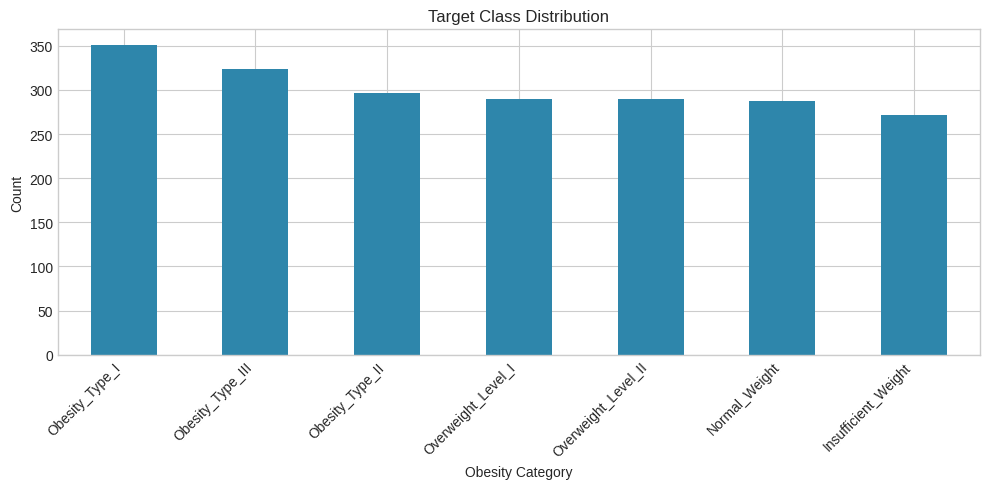

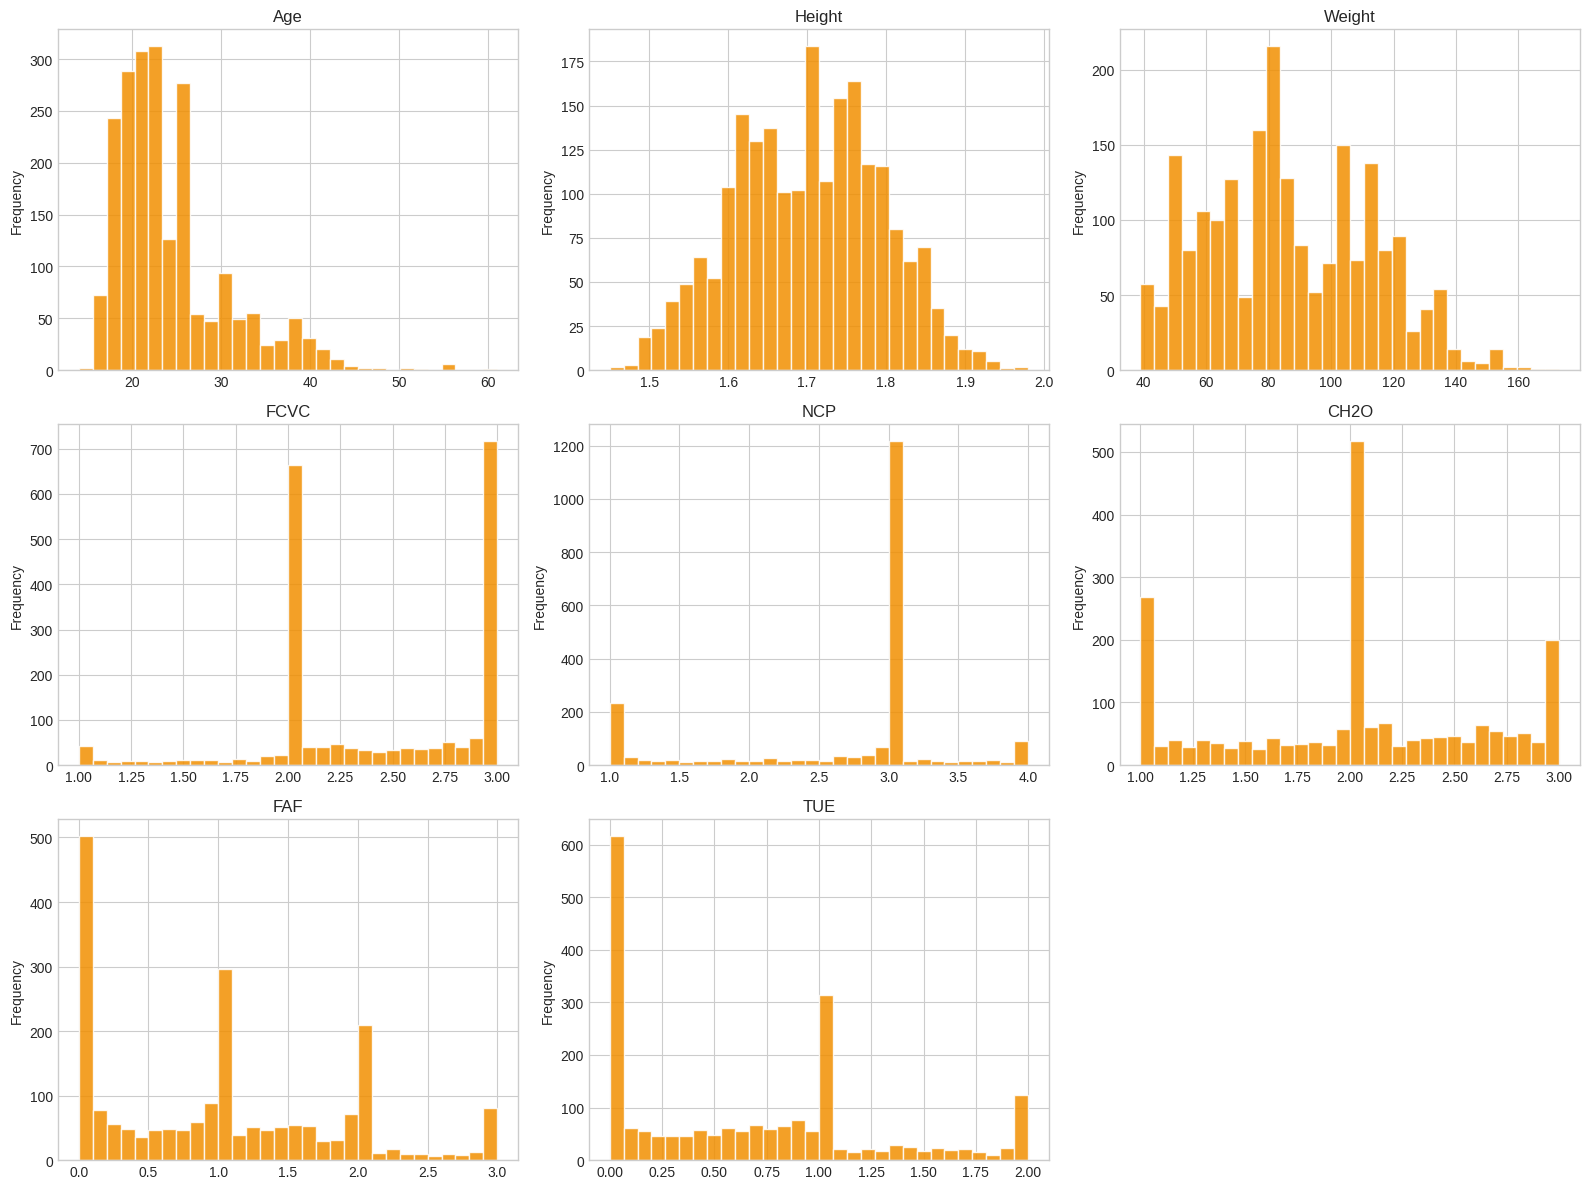

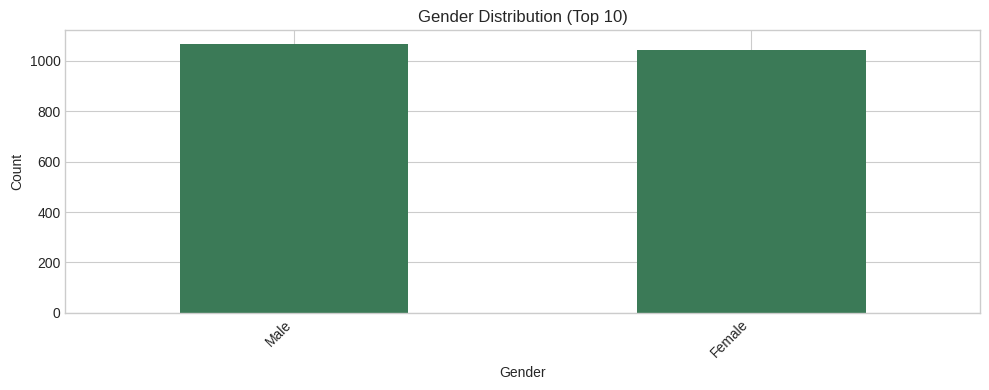

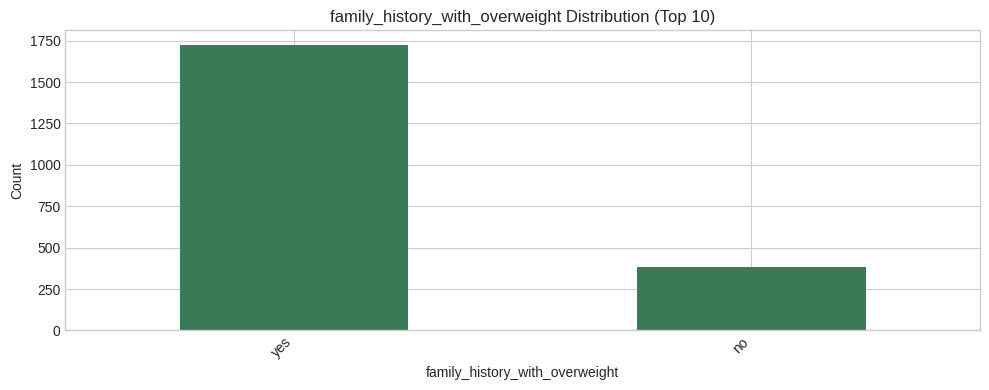

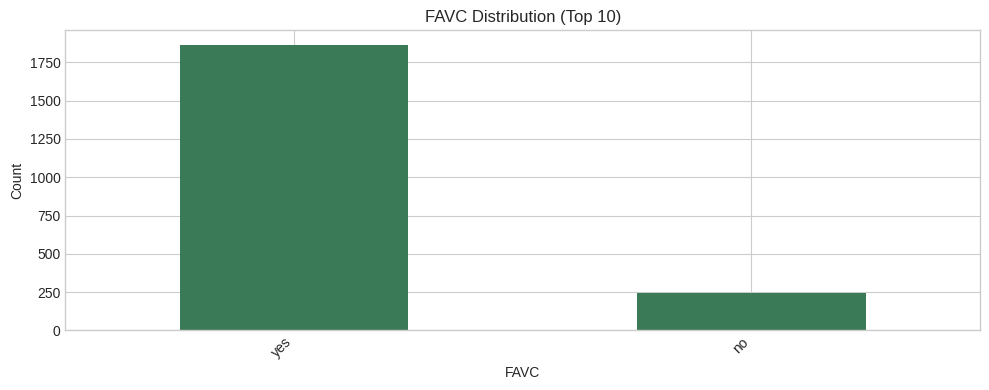

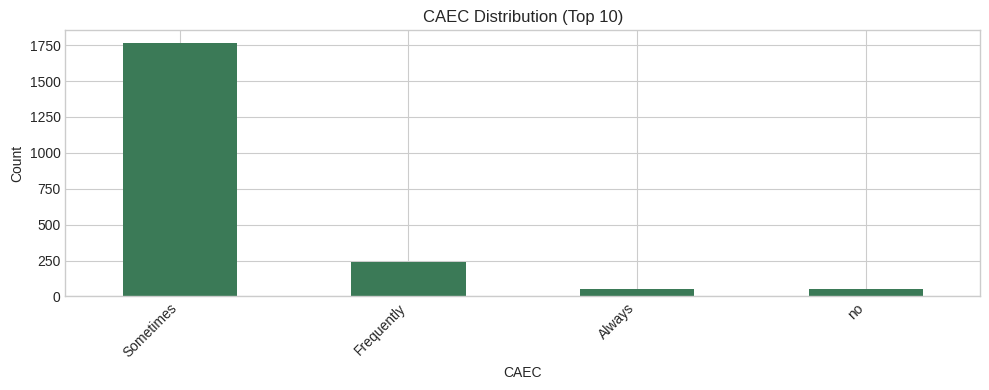

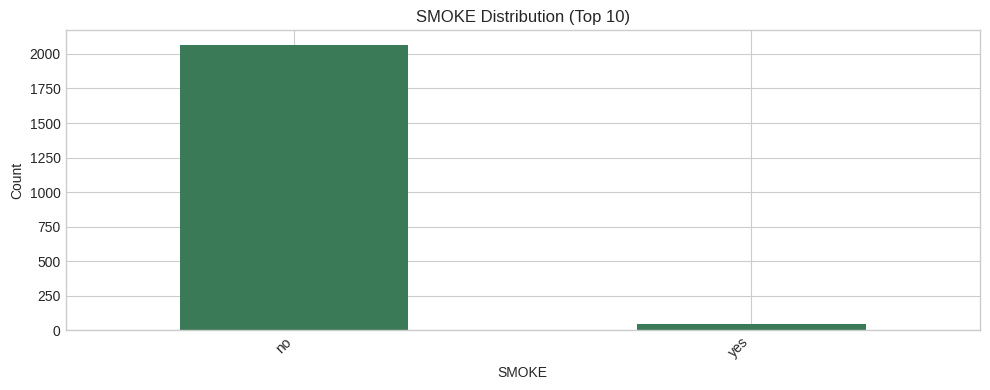

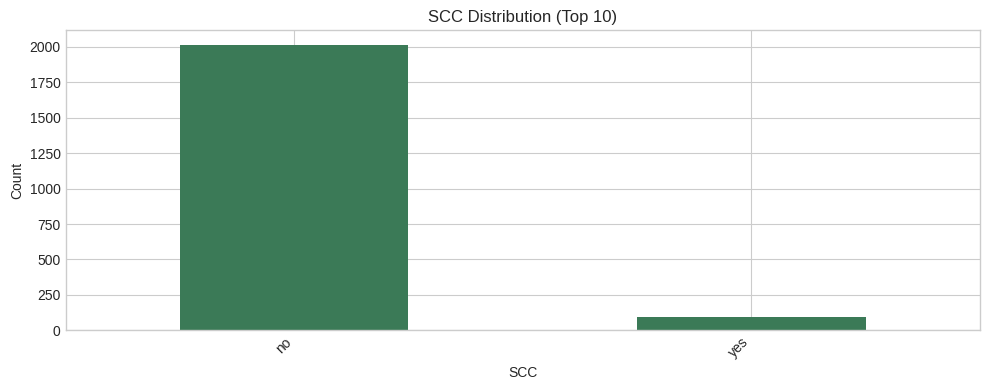

In [4]:
# Split columns by type
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = [col for col in df.columns if col not in numeric_cols]

target_col = 'NObeyesdad' if 'NObeyesdad' in df.columns else None

# Plot setup
plt.style.use('seaborn-v0_8-whitegrid')

# Target distribution
if target_col:
    target_counts = df[target_col].value_counts().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    target_counts.plot(kind='bar', color='#2E86AB', ax=ax)
    ax.set_title('Target Class Distribution')
    ax.set_xlabel('Obesity Category')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Numeric feature distributions
plot_numeric_cols = [col for col in numeric_cols if col != target_col]
if plot_numeric_cols:
    n_cols = 3
    n_rows = (len(plot_numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, col in zip(axes, plot_numeric_cols):
        ax.hist(df[col].dropna(), bins=30, color='#F18F01', alpha=0.85, edgecolor='white')
        ax.set_title(col)
        ax.set_ylabel('Frequency')

    for ax in axes[len(plot_numeric_cols):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Categorical feature distributions
for col in [c for c in categorical_cols if c != target_col][:6]:
    counts = df[col].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10, 4))
    counts.plot(kind='bar', ax=ax, color='#3B7A57')
    ax.set_title(f'{col} Distribution (Top 10)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Grouped BMI view by target, if available
if target_col and 'BMI' in df.columns:
    bmi_summary = df.groupby(target_col)['BMI'].agg(['mean', 'median', 'count']).sort_values('mean')
    display(bmi_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    bmi_summary['mean'].plot(kind='bar', color='#6C5CE7', ax=ax)
    ax.set_title('Average BMI by Obesity Category')
    ax.set_xlabel('Obesity Category')
    ax.set_ylabel('Mean BMI')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

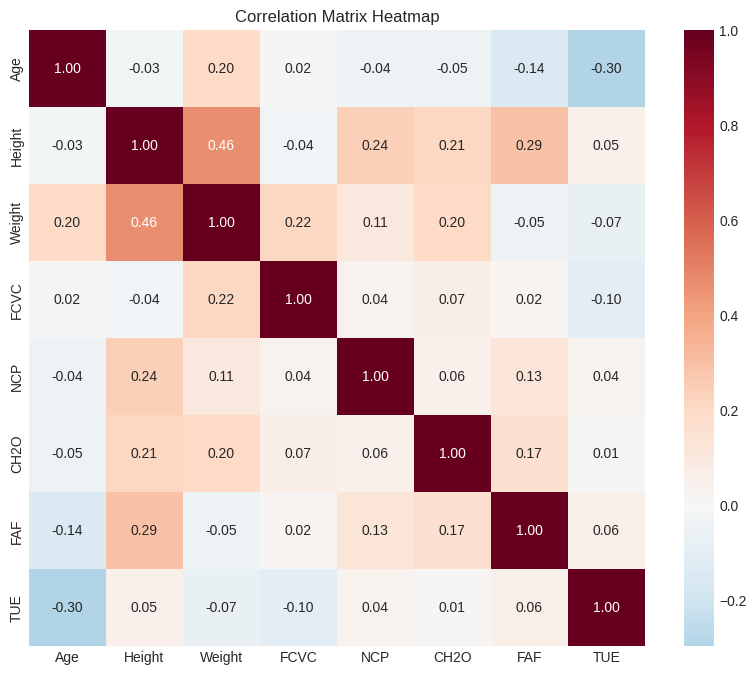

In [5]:
# I mik created
corr_matrix = df[plot_numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,     # Show the numeric values in cells
            fmt=".2f",      # Format to 2 decimal places
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            square=True)    # Make cells square

plt.title('Correlation Matrix Heatmap')
plt.show()


Obese dataframe shape: (972, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
10,Male,26.0,1.85,105.0,yes,yes,3.0,3.0,Frequently,no,3.0,no,2.0,2.0,Sometimes,Public_Transportation,Obesity_Type_I
13,Male,41.0,1.80,99.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Automobile,Obesity_Type_I
17,Female,29.0,1.53,78.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,no,Automobile,Obesity_Type_I
21,Female,52.0,1.69,87.0,yes,yes,3.0,1.0,Sometimes,yes,2.0,no,0.0,0.0,no,Automobile,Obesity_Type_I
23,Female,22.0,1.60,82.0,yes,yes,1.0,1.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Obesity_Type_I


,count
Gender,
Male,491
Female,481


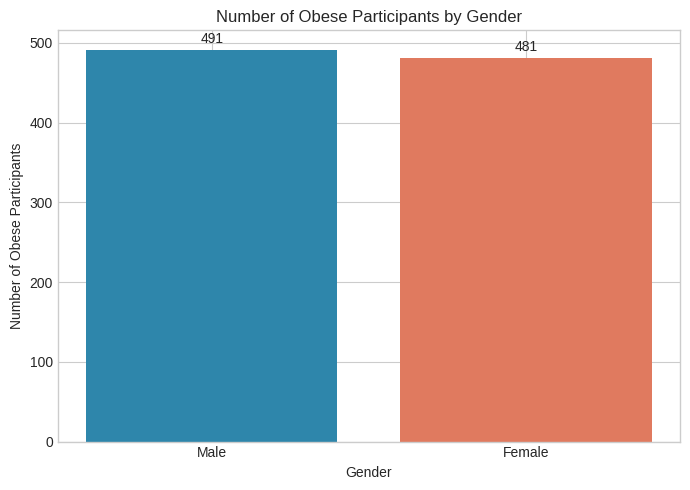

In [6]:
# Create a dataframe with obese people only
obese_df = df[df['NObeyesdad'].str.startswith('Obesity')].copy()

print(f'Obese dataframe shape: {obese_df.shape}')
display(obese_df.head())

# Compare the amount of obese male and female participants
obese_gender_counts = obese_df['Gender'].value_counts().reindex(['Male', 'Female'])
display(obese_gender_counts.to_frame('count'))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(obese_gender_counts.index, obese_gender_counts.values, color=['#2E86AB', '#E07A5F'])

ax.set_title('Number of Obese Participants by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Obese Participants')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
encoded_data = le.fit_transform(df["NObeyesdad"])

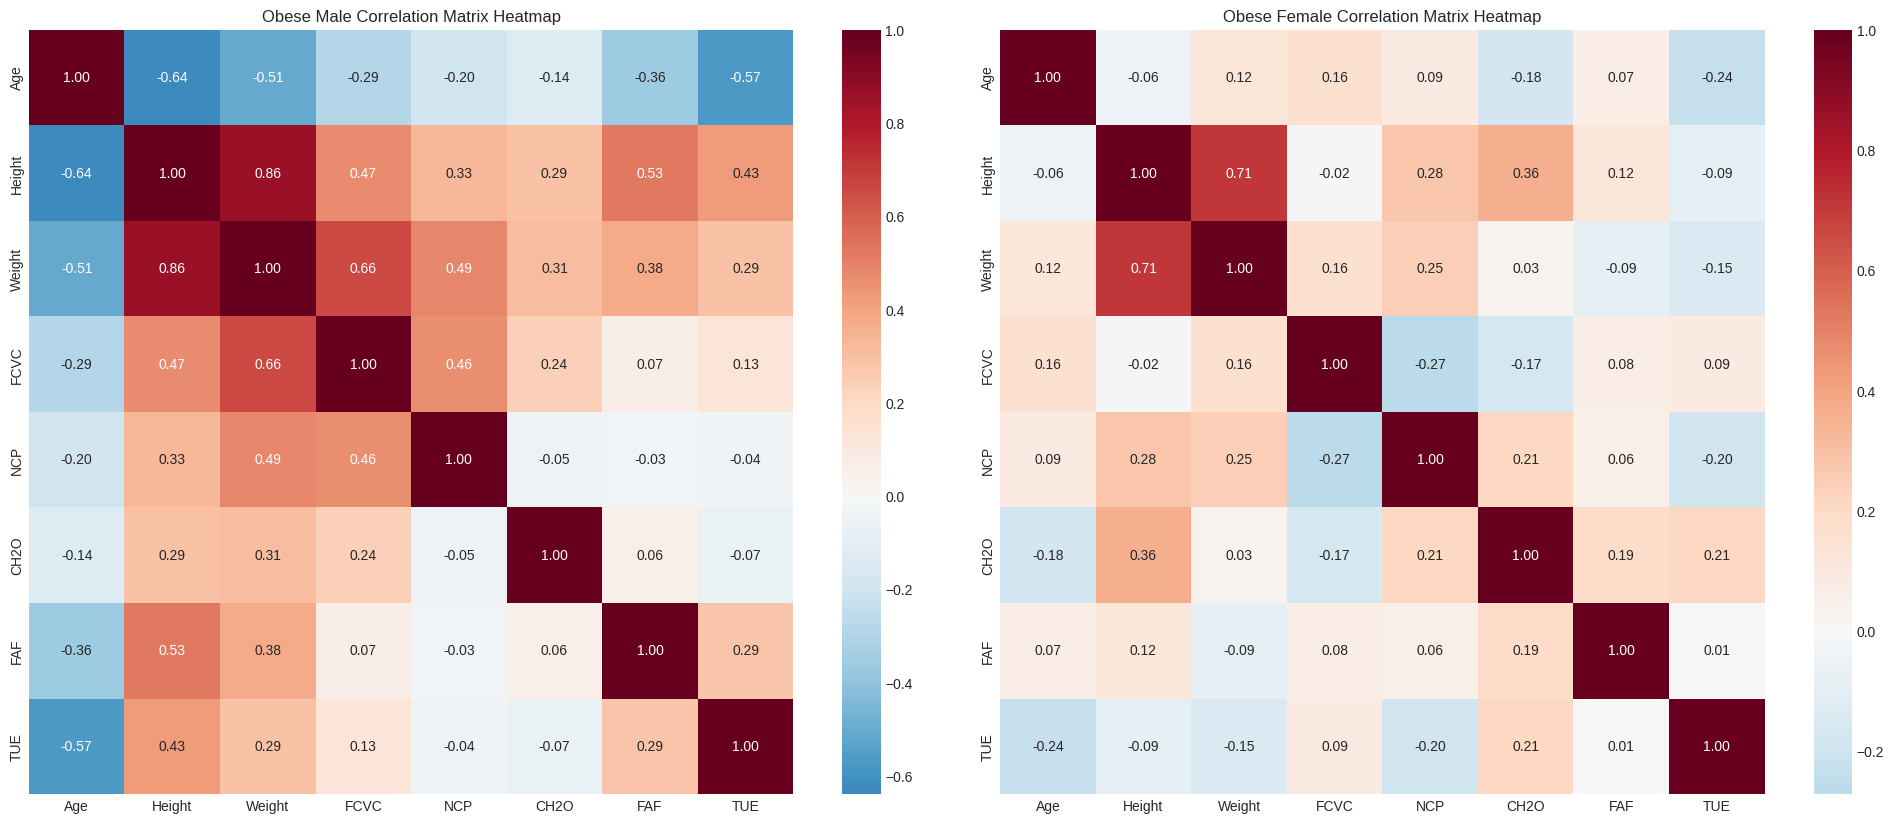

In [8]:
male_obese = pd.read_csv("../data/processed/Obese_Female.csv")
female_obese = pd.read_csv("../data/processed/Obese_Male.csv")

corr_male_obese = male_obese[plot_numeric_cols].corr()
corr_female_obese = female_obese[plot_numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_male_obese, annot=True, fmt=".2f", cmap='RdBu_r', center=0, square=True, ax=axes[0])
axes[0].set_title('Obese Male Correlation Matrix Heatmap')

sns.heatmap(corr_female_obese, annot=True, fmt=".2f", cmap='RdBu_r', center=0, square=True, ax=axes[1])
axes[1].set_title('Obese Female Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

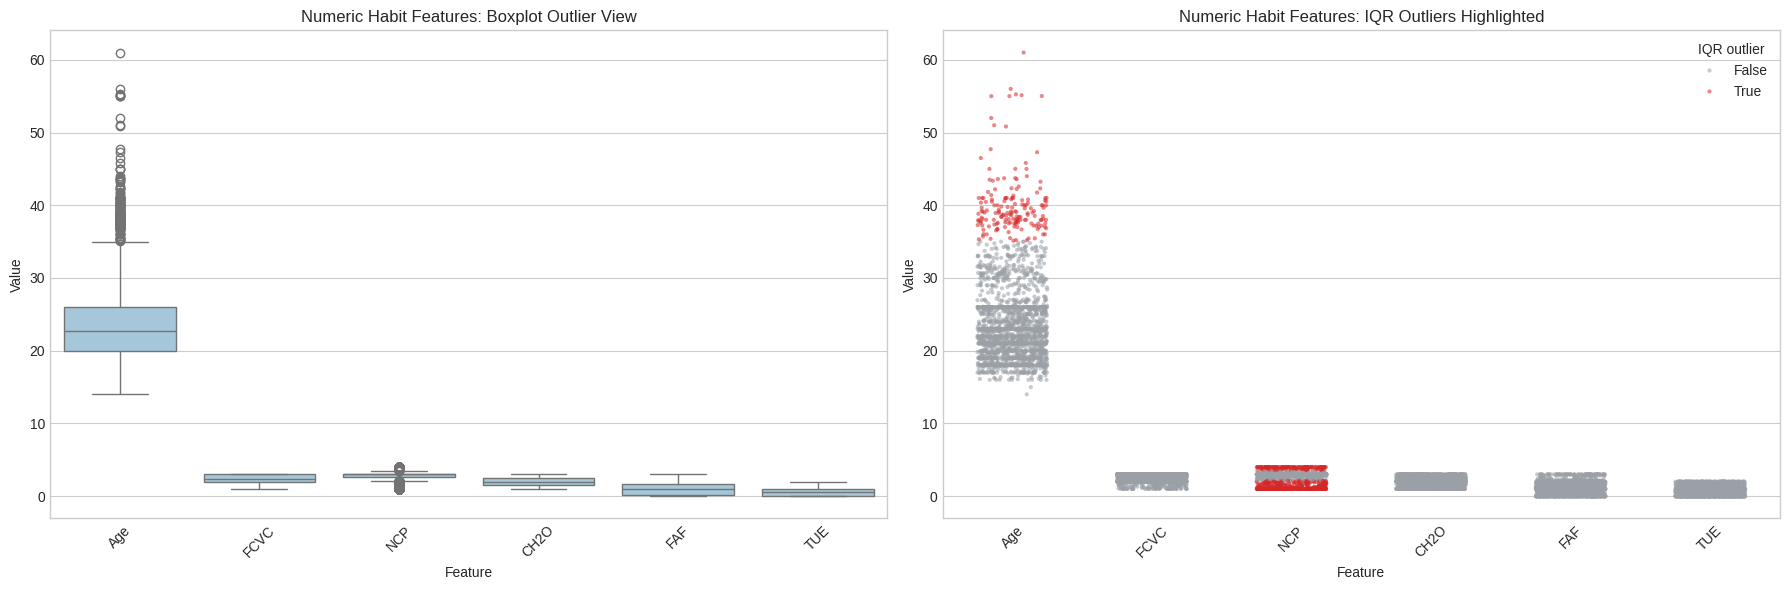

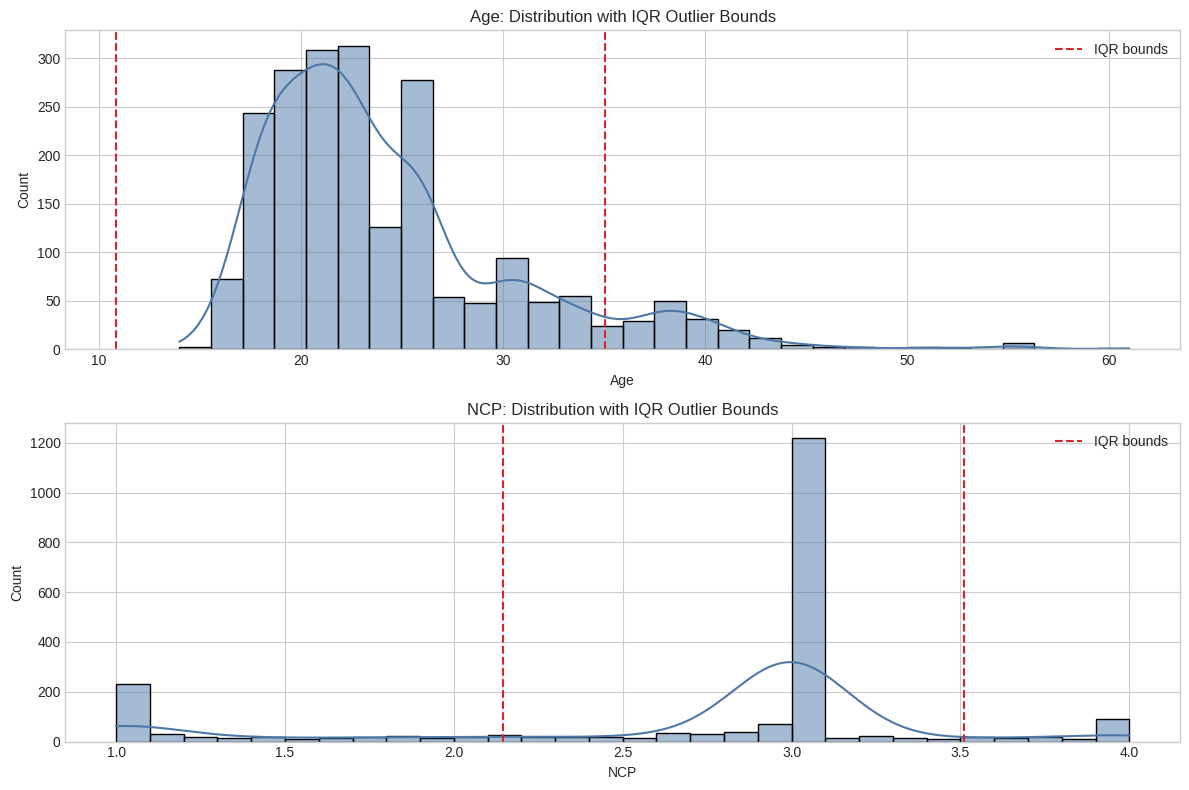

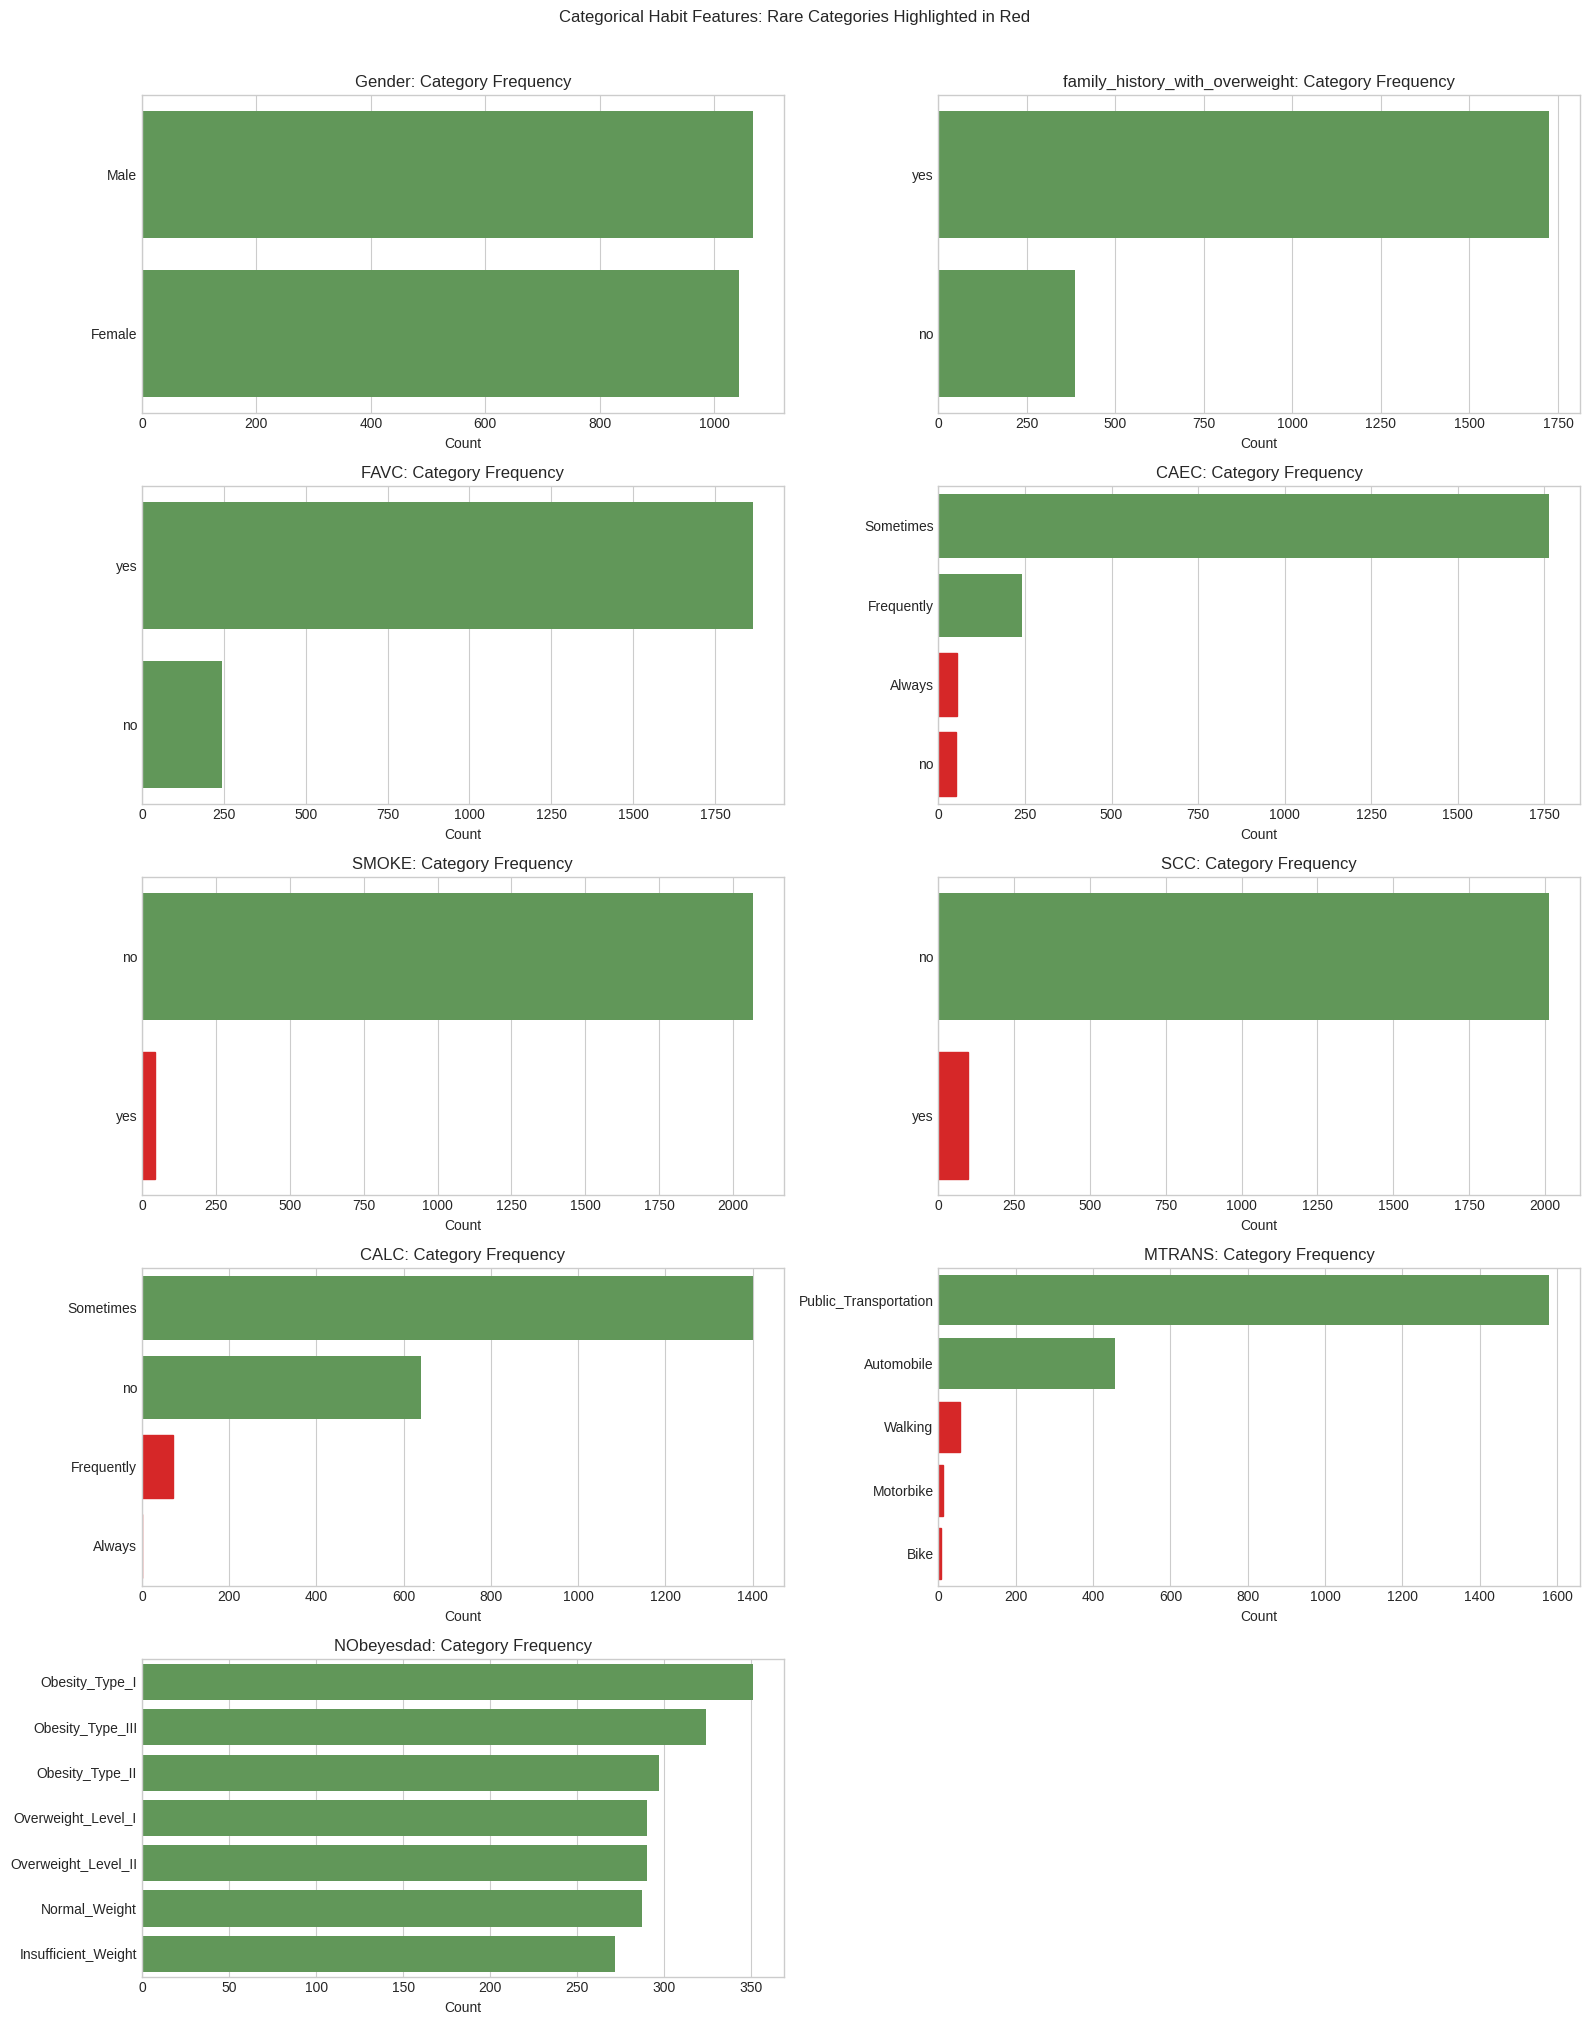

In [12]:
# 1. Your initial setup
new_df = df.drop(["Weight", "Height"], axis=1)

# 2. FIX: Define the columns using select_dtypes
numeric_habit_cols = new_df.select_dtypes(include='number').columns.tolist()
categorical_habit_cols = new_df.select_dtypes(exclude='number').columns.tolist()

# 3. FIX: Define the rare category threshold (e.g., 5%)
rare_threshold = 0.05 

# 4. FIX: Calculate the IQR to create 'outlier_masks' and 'outlier_summary'
outlier_masks = {}
summary_list = []

for col in numeric_habit_cols:
    Q1 = new_df[col].quantile(0.25)
    Q3 = new_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create a boolean mask (True if outlier, False if normal)
    mask = (new_df[col] < lower_bound) | (new_df[col] > upper_bound)
    outlier_masks[col] = mask
    
    # Save the summary stats for the histogram plots later
    summary_list.append({
        'feature': col,
        'outlier_count': mask.sum(),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    })

outlier_summary = pd.DataFrame(summary_list)

# ---------------------------------------------------------
# YOUR ORIGINAL VISUALIZATION CODE (Unchanged)
# ---------------------------------------------------------

plot_parts = []

for col in numeric_habit_cols:
    plot_parts.append(pd.DataFrame({
        'feature': col,
        'value': new_df[col],
        'is_outlier': outlier_masks[col]
    }))

if plot_parts:
    numeric_habit_plot_df = pd.concat(plot_parts, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.boxplot(data=numeric_habit_plot_df, x='feature', y='value', ax=axes[0], color='#9ecae1')
    axes[0].set_title('Numeric Habit Features: Boxplot Outlier View')
    axes[0].set_xlabel('Feature')
    axes[0].set_ylabel('Value')
    axes[0].tick_params(axis='x', rotation=45)

    sns.stripplot(
        data=numeric_habit_plot_df,
        x='feature',
        y='value',
        hue='is_outlier',
        jitter=0.25,
        alpha=0.55,
        size=3,
        palette={False: '#9aa0a6', True: '#d62728'},
        ax=axes[1]
    )
    axes[1].set_title('Numeric Habit Features: IQR Outliers Highlighted')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Value')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='IQR outlier')

    plt.tight_layout()
    plt.show()

outlier_features = outlier_summary.loc[outlier_summary['outlier_count'] > 0, 'feature']

if len(outlier_features) > 0:
    fig, axes = plt.subplots(len(outlier_features), 1, figsize=(12, 4 * len(outlier_features)))
    if len(outlier_features) == 1:
        axes = [axes]

    for ax, feature in zip(axes, outlier_features):
        sns.histplot(new_df[feature], kde=True, bins=30, color='#4c78a8', ax=ax)
        bounds = outlier_summary.set_index('feature').loc[feature, ['lower_bound', 'upper_bound']]
        ax.axvline(bounds['lower_bound'], color='#d62728', linestyle='--', label='IQR bounds')
        ax.axvline(bounds['upper_bound'], color='#d62728', linestyle='--')
        ax.set_title(f'{feature}: Distribution with IQR Outlier Bounds')
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No numeric habit outliers found with the IQR method.')

if categorical_habit_cols:
    n_cols = 2
    n_rows = (len(categorical_habit_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, col in zip(axes, categorical_habit_cols):
        category_order = new_df[col].value_counts(dropna=False).index
        sns.countplot(data=new_df, y=col, order=category_order, color='#59a14f', ax=ax)
        ax.set_title(f'{col}: Category Frequency')
        ax.set_xlabel('Count')
        ax.set_ylabel('')

        total = len(new_df)
        for patch in ax.patches:
            count = patch.get_width()
            percent = count / total * 100
            if percent < rare_threshold * 100:
                patch.set_color('#d62728')

    for ax in axes[len(categorical_habit_cols):]:
        ax.set_visible(False)

    fig.suptitle('Categorical Habit Features: Rare Categories Highlighted in Red', y=1.01)
    plt.tight_layout()
    plt.show()

Age                                              FCVC  \
                    count       mean     median       std   min   max count   
NObeyesdad                                                                    
Insufficient_Weight   272  19.783237  19.244594  2.669511  16.0  39.0   272   
Normal_Weight         287  21.738676  21.000000  5.096756  14.0  61.0   287   
Obesity_Type_I        351  25.884941  22.975526  7.755700  15.0  52.0   351   
Obesity_Type_II       297  28.233785  27.186873  4.868199  20.0  41.0   297   
Obesity_Type_III      324  23.495554  25.369387  2.764324  18.0  26.0   324   
Overweight_Level_I    290  23.417674  21.045204  6.125076  16.0  55.0   290   
Overweight_Level_II   290  26.996981  24.000000  8.061061  17.0  56.0   290   

                                                              NCP            \
                         mean    median       std  min  max count      mean   
NObeyesdad                                                                    
Insufficient_Weight  2.480788  2.708316  0.584797  1.0  3.0   272  2.914403   
Normal_Weight        2.334495  2.000000  0.590983  1.0  3.0   287  2.738676   
Obesity_Type_I       2.186050  2.000000  0.431998  1.0  3.0   351  2.431862   
Obesity_Type_II      2.391284  2.432355  0.489808  1.0  3.0   297  2.744555   
Obesity_Type_III     3.000000  3.000000  0.000000  3.0  3.0   324  3.000000   
Overweight_Level_I   2.264631  2.000000  0.482626  1.0  3.0   290  2.504218   
Overweight_Level_II  2.260578  2.000000  0.453272  1.0  3.0   290  2.495529   

                                                 CH2O                      \
                     median       std  min  max count      mean    median   
NObeyesdad                                                                  
Insufficient_Weight  3.0000  0.901268  1.0  4.0   272  1.871281  2.000000   
Normal_Weight        3.0000  0.871861  1.0  4.0   287  1.850174  2.000000   
Obesity_Type_I       3.0000  0.789471  1.0  3.0   351  2.112218  2.014990   
Obesity_Type_II      3.0000  0.578765  1.0  4.0   297  1.877658  2.001208   
Obesity_Type_III     3.0000  0.000000  3.0  3.0   324  2.208493  2.431036   
Overweight_Level_I   3.0000  0.962811  1.0  4.0   290  2.058725  2.000000   
Overweight_Level_II  2.9785  0.752908  1.0  4.0   290  2.025133  2.000000   

                                          FAF                                \
                          std  min  max count      mean    median       std   
NObeyesdad                                                                    
Insufficient_Weight  0.602295  1.0  3.0   272  1.250131  1.339914  0.856625   
Normal_Weight        0.638391  1.0  3.0   287  1.247387  1.000000  1.016362   
Obesity_Type_I       0.624644  1.0  3.0   351  0.986748  0.990642  0.894675   
Obesity_Type_II      0.553123  1.0  3.0   297  0.971857  0.994422  0.581238   
Obesity_Type_III     0.603782  1.0  3.0   324  0.664817  0.222654  0.732864   
Overweight_Level_I   0.615209  1.0  3.0   290  1.056796  1.000000  0.851600   
Overweight_Level_II  0.553960  1.0  3.0   290  0.958072  0.960716  0.824744   

                                TUE                                          
                     min  max count      mean    median       std  min  max  
NObeyesdad                                                                   
Insufficient_Weight  0.0  3.0   272  0.839459  1.000000  0.643231  0.0  2.0  
Normal_Weight        0.0  3.0   287  0.675958  1.000000  0.686697  0.0  2.0  
Obesity_Type_I       0.0  3.0   351  0.676743  0.537659  0.687897  0.0  2.0  
Obesity_Type_II      0.0  2.0   297  0.515186  0.343635  0.563862  0.0  2.0  
Obesity_Type_III     0.0  2.0   324  0.604623  0.656856  0.281852  0.0  1.0  
Overweight_Level_I   0.0  3.0   290  0.612992  0.363159  0.677714  0.0  2.0  
Overweight_Level_II  0.0  3.0   290  0.697275  0.754274  0.588436  0.0  2.0

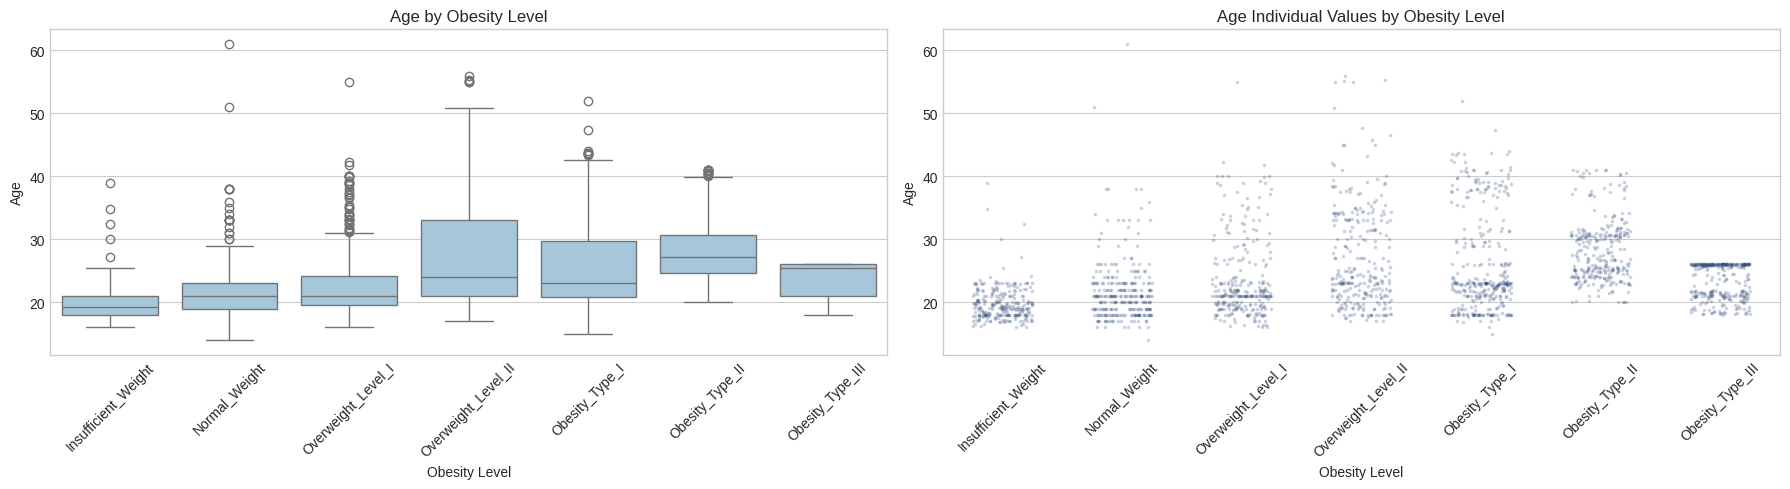

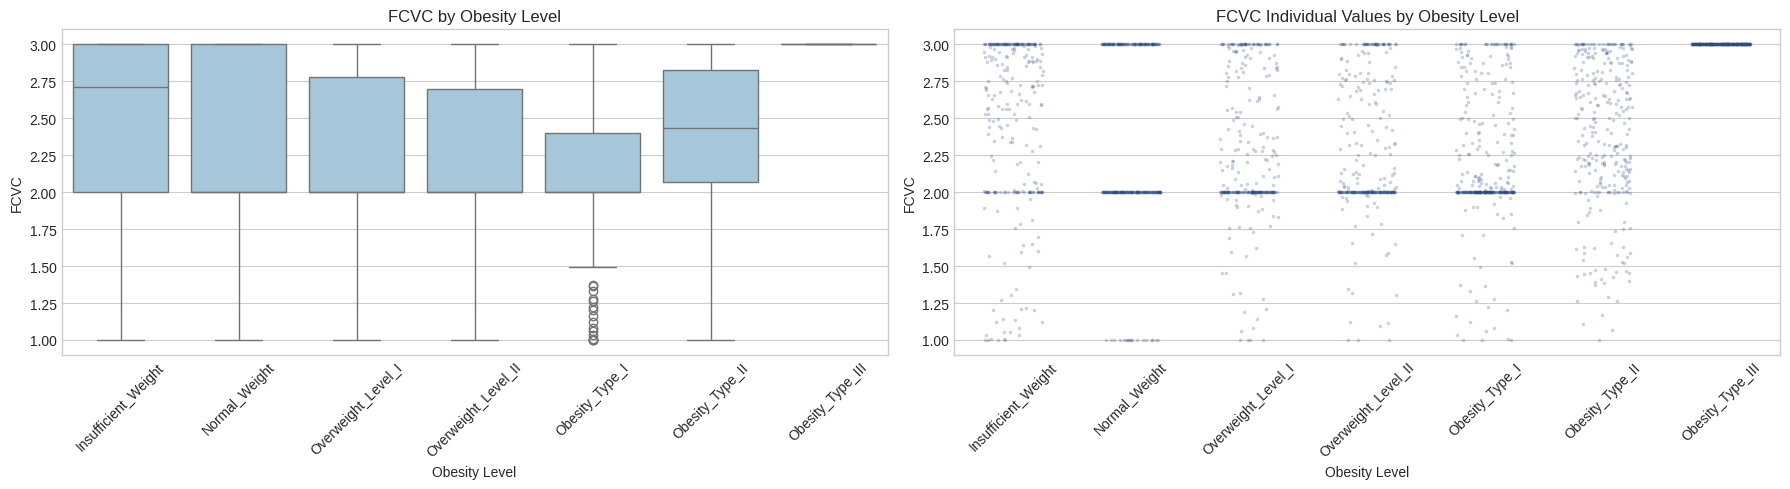

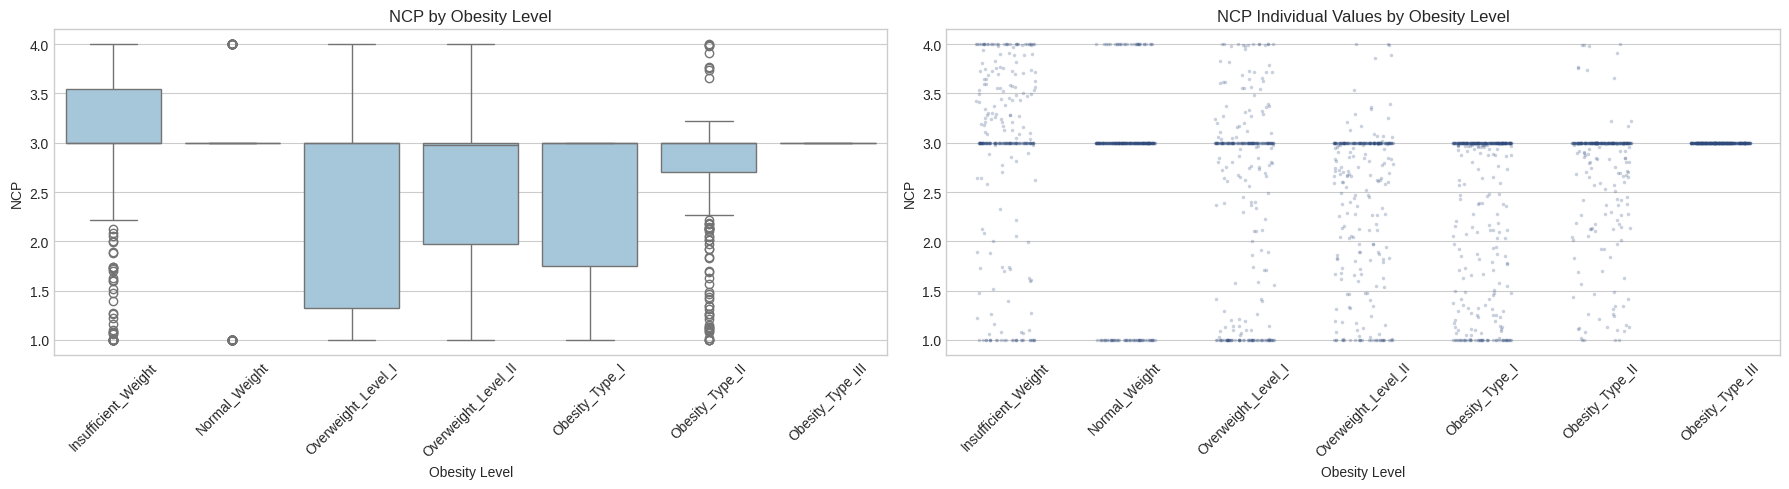

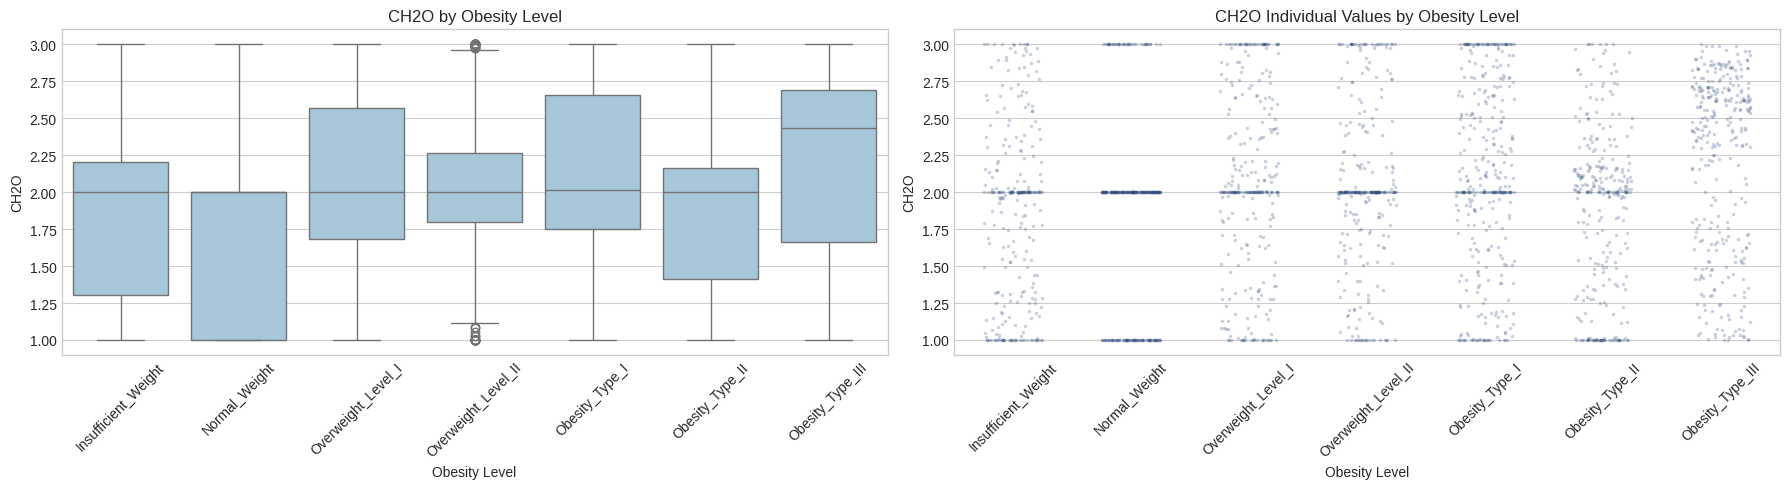

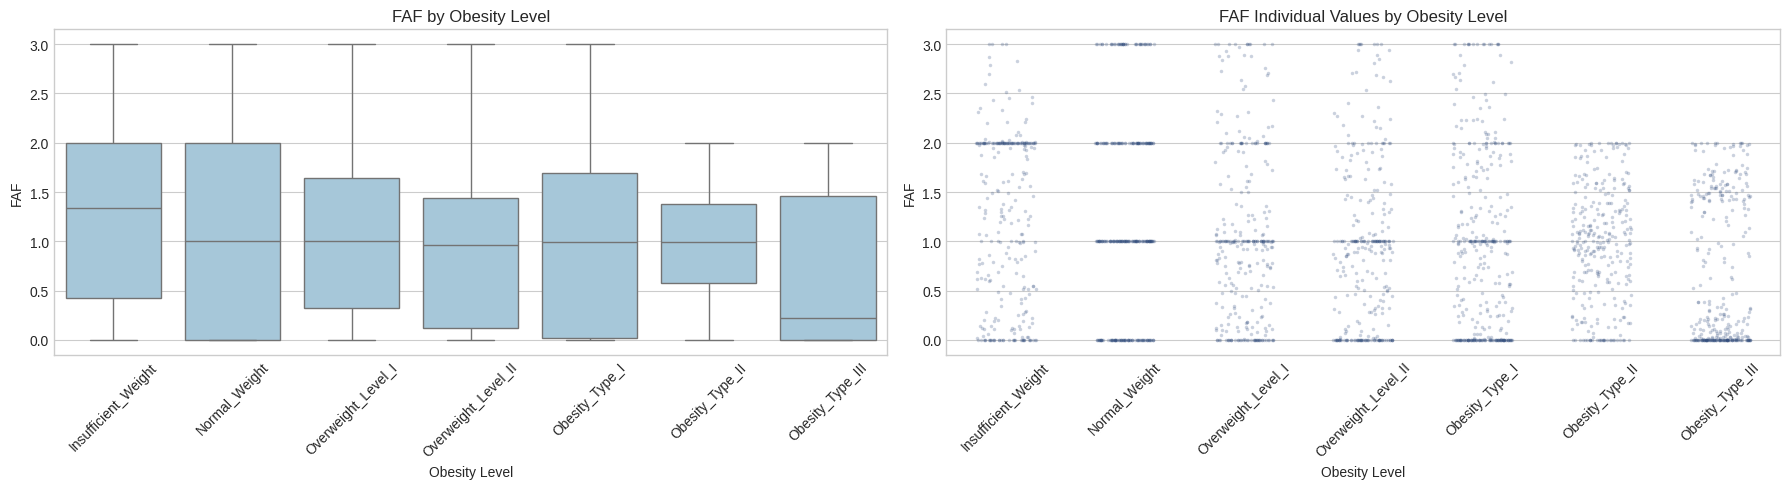

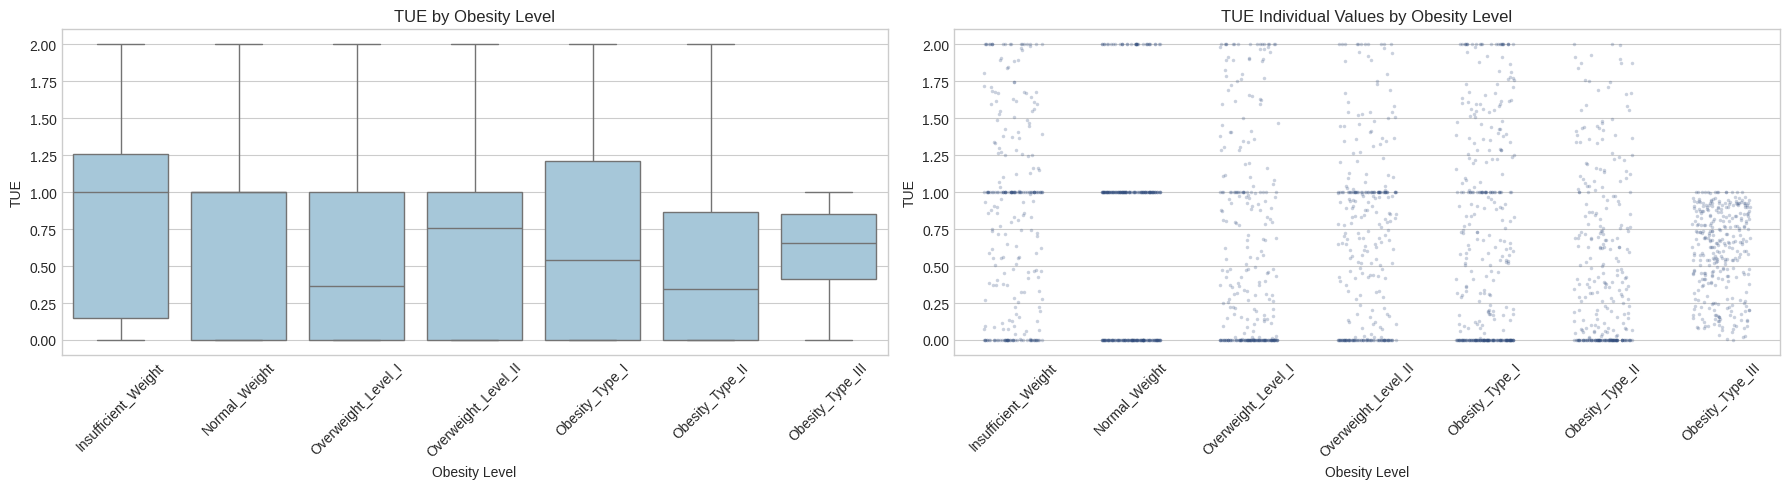

In [18]:
# 1. FIX: Define your target column name (Change this if your column is named differently)
target_col = 'NObeyesdad' 

# 2. FIX: Define the numeric columns you want to plot
# (Extracting all numeric columns except the target, just in case the target is encoded as numbers)
numeric_feature_cols = new_df.select_dtypes(include='number').columns.tolist()
if target_col in numeric_feature_cols:
    numeric_feature_cols.remove(target_col)

# 3. FIX: Define the logical order of your categories so the charts read left-to-right properly
# (Update these exact strings to match the unique values in your target_col)
obesity_order = [
    'Insufficient_Weight', 
    'Normal_Weight', 
    'Overweight_Level_I', 
    'Overweight_Level_II', 
    'Obesity_Type_I', 
    'Obesity_Type_II', 
    'Obesity_Type_III'
]

# ---------------------------------------------------------
# YOUR ORIGINAL VISUALIZATION CODE (Unchanged)
# ---------------------------------------------------------

# Numeric features vs obesity level, one-by-one
numeric_comparison_summary = (
    new_df
    .groupby(target_col)[numeric_feature_cols]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
)

display(numeric_comparison_summary)

for feature in numeric_feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sns.boxplot(
        data=new_df,
        x=target_col,
        y=feature,
        order=obesity_order,
        color='#9ecae1',
        ax=axes[0]
    )
    axes[0].set_title(f'{feature} by Obesity Level')
    axes[0].set_xlabel('Obesity Level')
    axes[0].set_ylabel(feature)
    axes[0].tick_params(axis='x', rotation=45)

    sns.stripplot(
        data=new_df,
        x=target_col,
        y=feature,
        order=obesity_order,
        color='#2f4b7c',
        alpha=0.25,
        jitter=0.25,
        size=2.5,
        ax=axes[1]
    )
    axes[1].set_title(f'{feature} Individual Values by Obesity Level')
    axes[1].set_xlabel('Obesity Level')
    axes[1].set_ylabel(feature)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


Gender vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,173,141,156,2,323,145,103
Male,99,146,195,295,1,145,187


Gender vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,16.59,13.52,14.96,0.19,30.97,13.90,9.88
Male,9.27,13.67,18.26,27.62,0.09,13.58,17.51


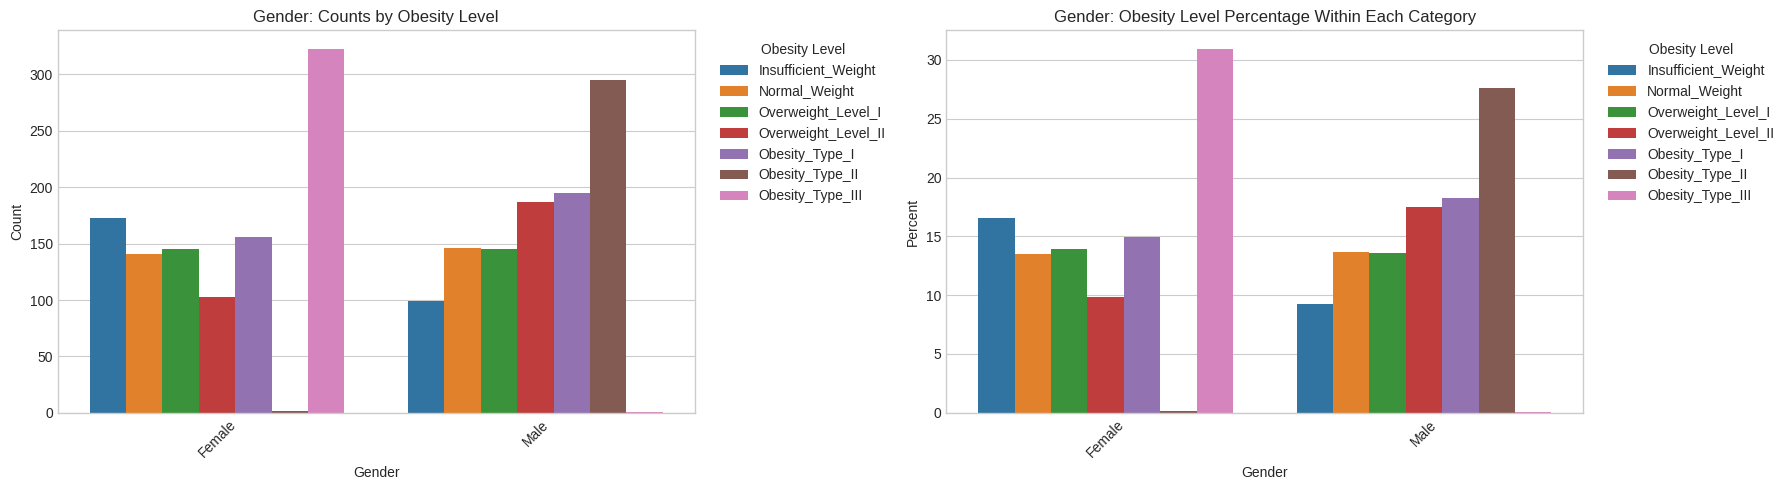


family_history_with_overweight vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history_with_overweight,,,,,,,
no,146,132,7,1,0,81,18
yes,126,155,344,296,324,209,272


family_history_with_overweight vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history_with_overweight,,,,,,,
no,37.92,34.29,1.82,0.26,0.00,21.04,4.68
yes,7.30,8.98,19.93,17.15,18.77,12.11,15.76


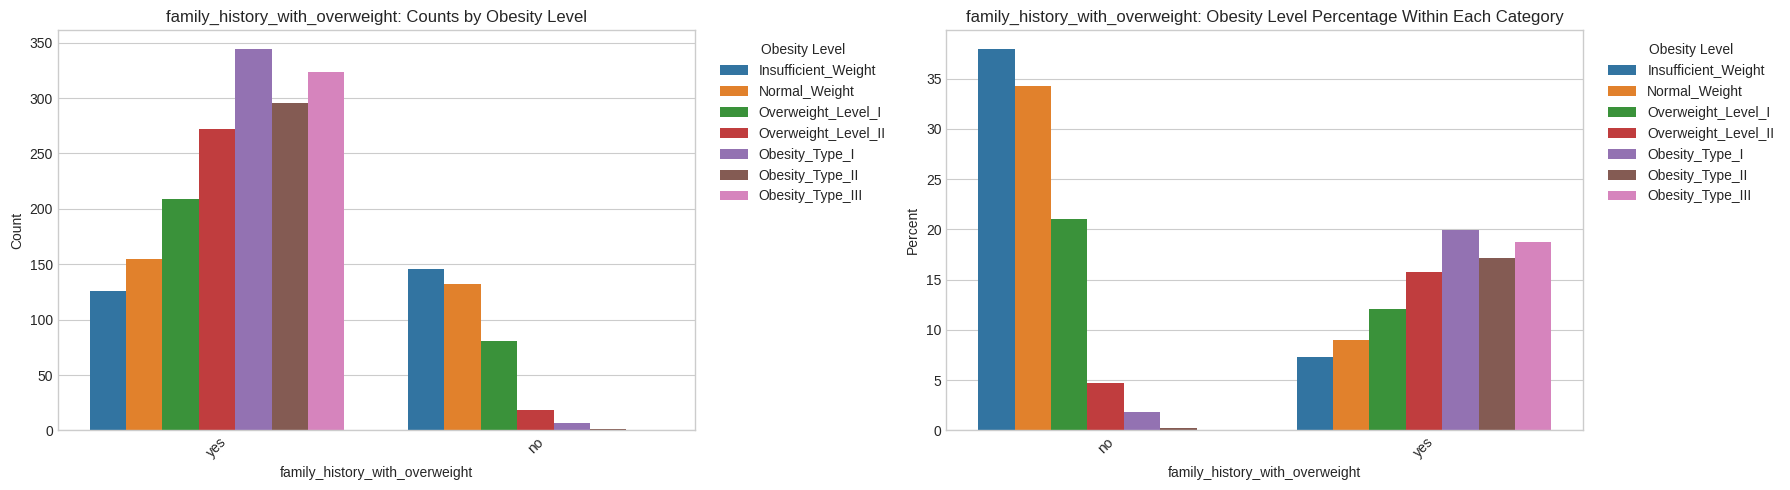


FAVC vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FAVC,,,,,,,
no,51,79,11,7,1,22,74
yes,221,208,340,290,323,268,216


FAVC vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FAVC,,,,,,,
no,20.82,32.24,4.49,2.86,0.41,8.98,30.20
yes,11.84,11.15,18.22,15.54,17.31,14.36,11.58


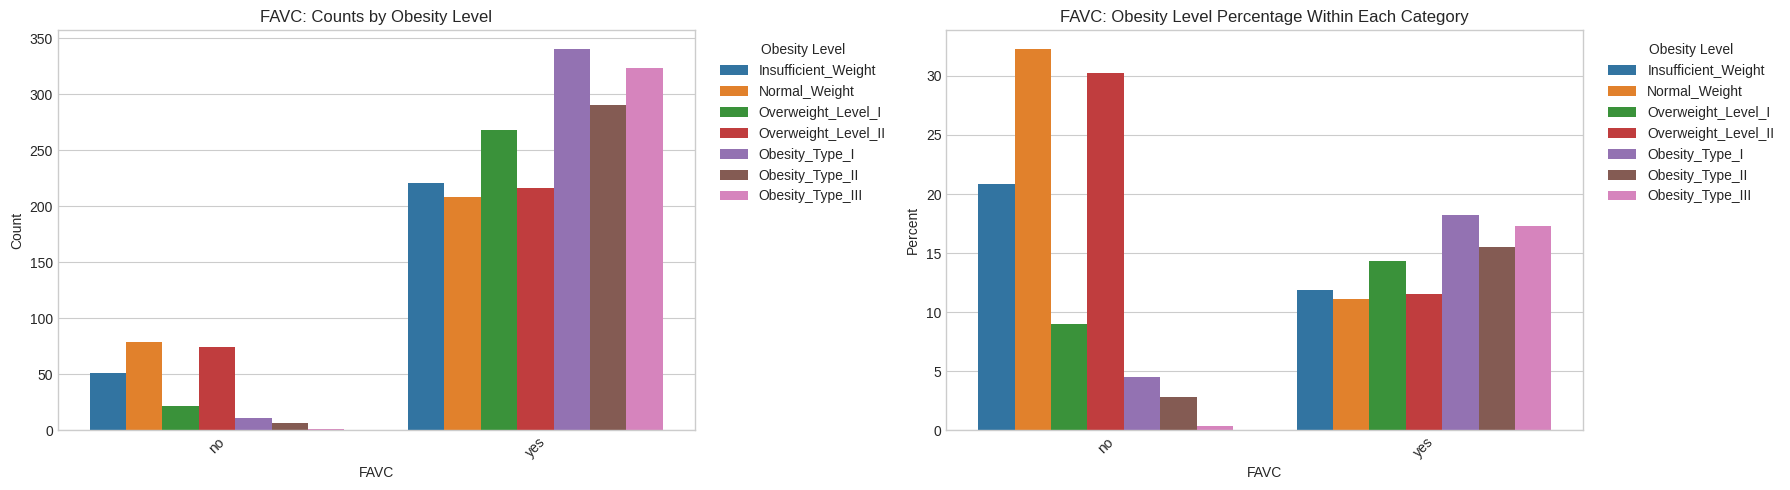


CAEC vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CAEC,,,,,,,
Always,2,35,6,2,0,5,3
Frequently,121,83,6,1,1,14,16
Sometimes,146,159,338,293,323,236,270
no,3,10,1,1,0,35,1


CAEC vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CAEC,,,,,,,
Always,3.77,66.04,11.32,3.77,0.00,9.43,5.66
Frequently,50.00,34.30,2.48,0.41,0.41,5.79,6.61
Sometimes,8.27,9.01,19.15,16.60,18.30,13.37,15.30
no,5.88,19.61,1.96,1.96,0.00,68.63,1.96


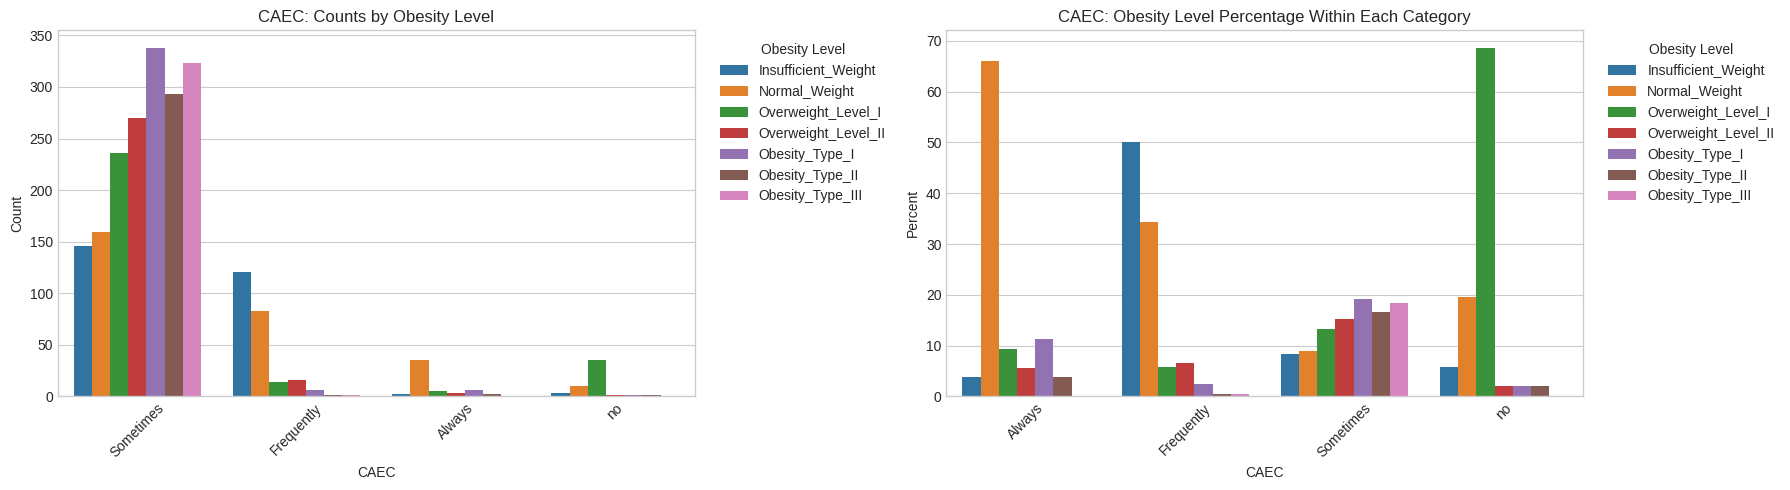


SMOKE vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SMOKE,,,,,,,
no,271,274,345,282,323,287,285
yes,1,13,6,15,1,3,5


SMOKE vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SMOKE,,,,,,,
no,13.11,13.26,16.69,13.64,15.63,13.88,13.79
yes,2.27,29.55,13.64,34.09,2.27,6.82,11.36


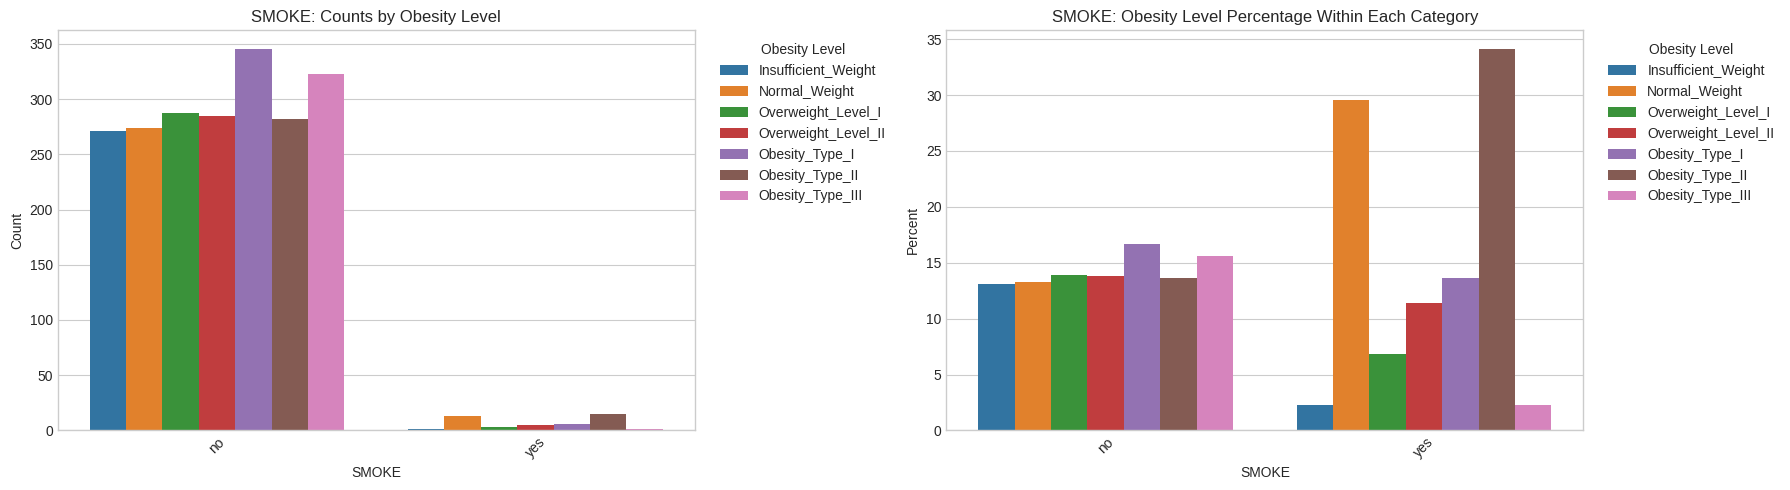


SCC vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SCC,,,,,,,
no,250,257,349,296,324,253,286
yes,22,30,2,1,0,37,4


SCC vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SCC,,,,,,,
no,12.41,12.75,17.32,14.69,16.08,12.56,14.19
yes,22.92,31.25,2.08,1.04,0.00,38.54,4.17


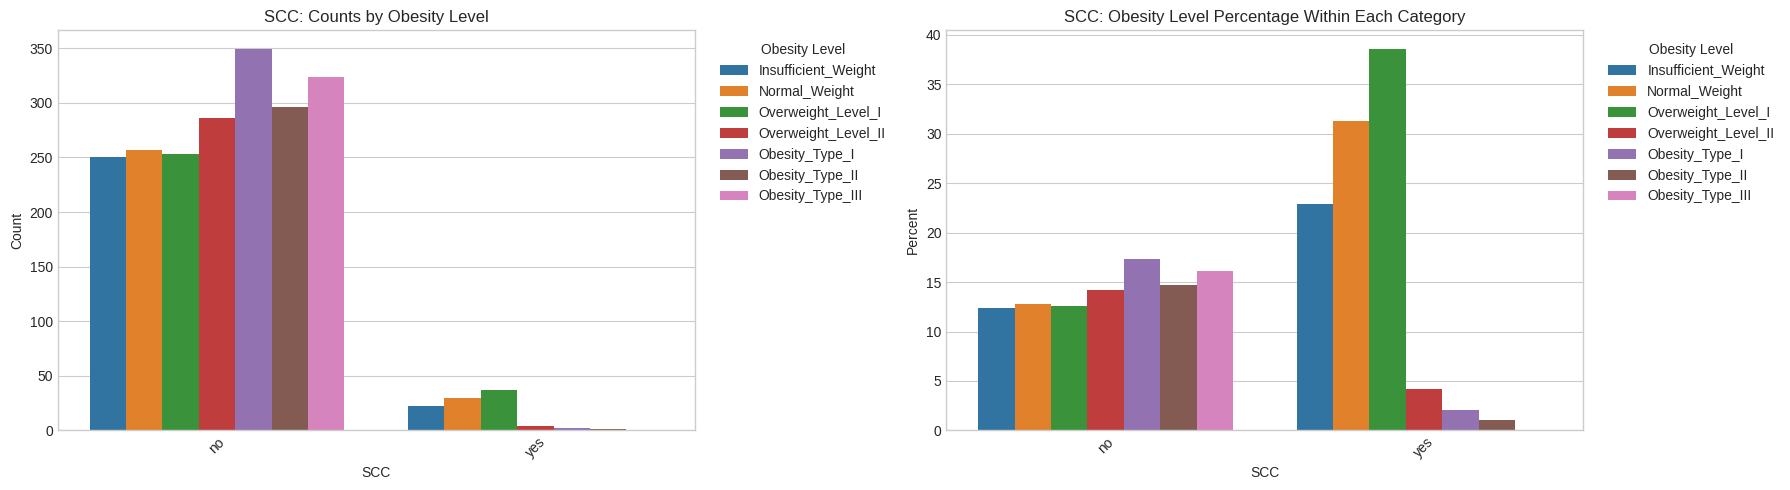


CALC vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CALC,,,,,,,
Always,0,1,0,0,0,0,0
Frequently,1,18,14,2,0,16,19
Sometimes,154,161,172,224,323,224,143
no,117,107,165,71,1,50,128


CALC vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CALC,,,,,,,
Always,0.00,100.00,0.00,0.00,0.00,0.00,0.00
Frequently,1.43,25.71,20.00,2.86,0.00,22.86,27.14
Sometimes,10.99,11.49,12.28,15.99,23.05,15.99,10.21
no,18.31,16.74,25.82,11.11,0.16,7.82,20.03


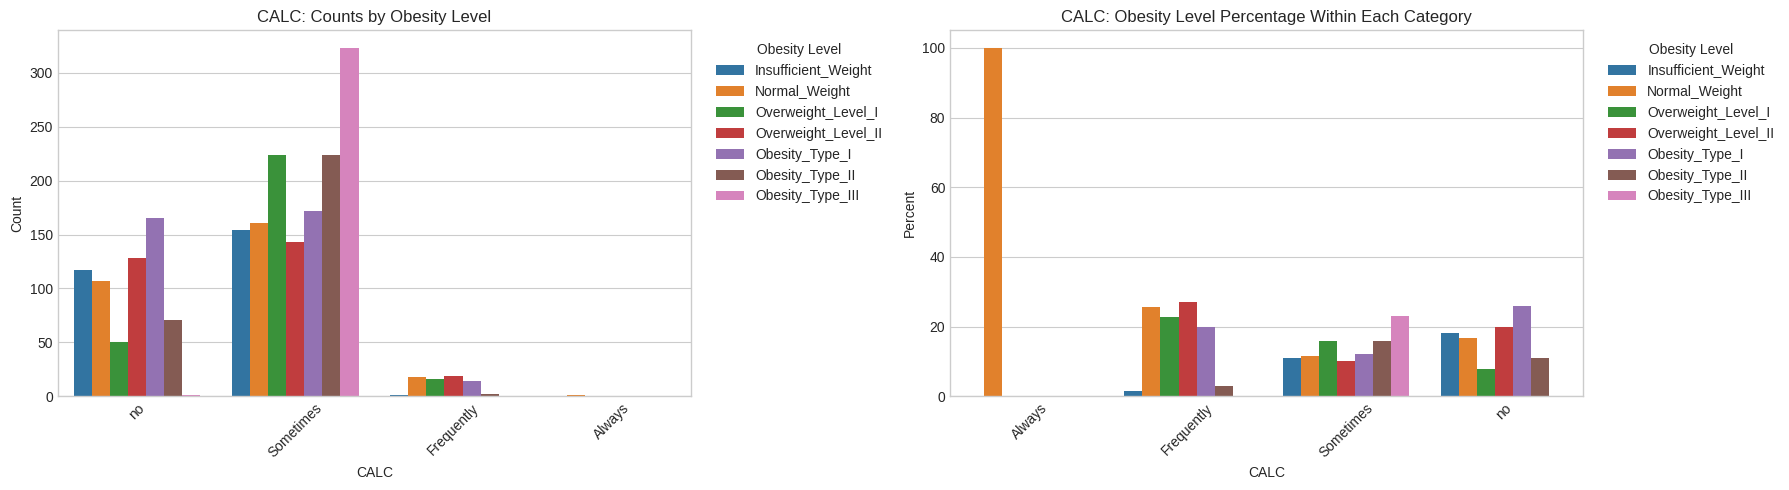


MTRANS vs NObeyesdad: counts


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
MTRANS,,,,,,,
Automobile,46,45,110,95,1,66,94
Bike,0,4,0,1,0,2,0
Motorbike,0,6,3,0,0,1,1
Public_Transportation,220,200,236,200,323,212,189
Walking,6,32,2,1,0,9,6


MTRANS vs NObeyesdad: row percentages


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
MTRANS,,,,,,,
Automobile,10.07,9.85,24.07,20.79,0.22,14.44,20.57
Bike,0.00,57.14,0.00,14.29,0.00,28.57,0.00
Motorbike,0.00,54.55,27.27,0.00,0.00,9.09,9.09
Public_Transportation,13.92,12.66,14.94,12.66,20.44,13.42,11.96
Walking,10.71,57.14,3.57,1.79,0.00,16.07,10.71


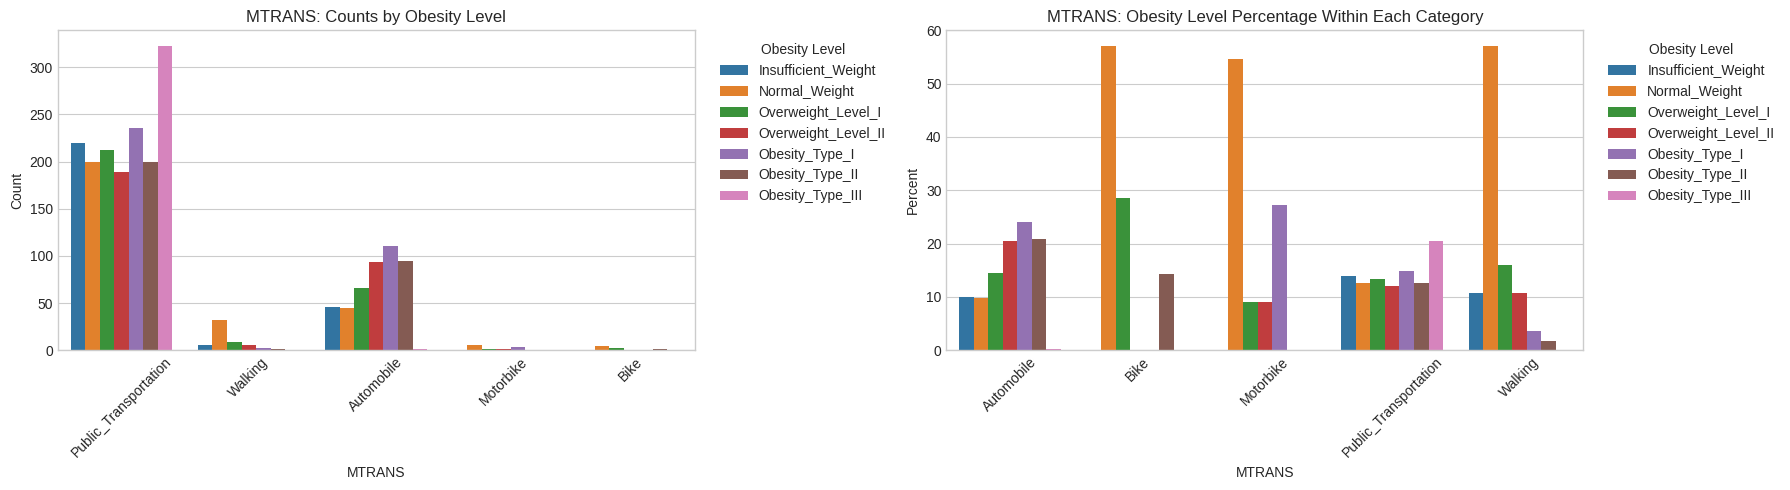

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. FIX: Define the categorical columns you want to plot
# (Extracting all non-numeric columns. We also remove the target column so it doesn't plot against itself!)
categorical_feature_cols = new_df.select_dtypes(exclude='number').columns.tolist()
if target_col in categorical_feature_cols:
    categorical_feature_cols.remove(target_col)

# ---------------------------------------------------------
# YOUR ORIGINAL VISUALIZATION CODE (Unchanged)
# ---------------------------------------------------------

# Categorical features vs obesity level, one-by-one
for feature in categorical_feature_cols:
    count_table = pd.crosstab(new_df[feature], new_df[target_col])
    percent_table = pd.crosstab(
        new_df[feature],
        new_df[target_col],
        normalize='index'
    ) * 100

    print(f'\n{feature} vs {target_col}: counts')
    display(count_table)

    print(f'{feature} vs {target_col}: row percentages')
    display(percent_table.round(2))

    percent_plot_df = (
        percent_table
        .reset_index()
        .melt(id_vars=feature, var_name=target_col, value_name='percent')
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sns.countplot(
        data=new_df,
        x=feature,
        hue=target_col,
        hue_order=obesity_order, # Assuming obesity_order is still in memory from the previous cell
        ax=axes[0]
    )
    axes[0].set_title(f'{feature}: Counts by Obesity Level')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Move the legend outside the plot so it doesn't cover your bars
    axes[0].legend(title='Obesity Level', bbox_to_anchor=(1.02, 1), loc='upper left')

    sns.barplot(
        data=percent_plot_df,
        x=feature,
        y='percent',
        hue=target_col,
        hue_order=obesity_order,
        ax=axes[1]
    )
    axes[1].set_title(f'{feature}: Obesity Level Percentage Within Each Category')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Percent')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Move the legend outside the plot
    axes[1].legend(title='Obesity Level', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

In [21]:
# Assuming your dataframe is loaded as 'df'

# ---------------------------------------------------------
# 1. Basal Metabolic Rate (BMR) - Mifflin-St Jeor Equation
# ---------------------------------------------------------
# Note: The UCI Obesity dataset typically stores 'Height' in meters. 
# The Mifflin-St Jeor formula requires height in centimeters.
height_cm = df['Height'] * 100

# Calculate the base equation shared by both genders
base_bmr = (10 * df['Weight']) + (6.25 * height_cm) - (5 * df['Age'])

# Apply gender-specific modifiers using a vectorized conditional
df['BMR'] = np.where(
    df['Gender'] == 'Male', 
    base_bmr + 5,       # Male adjustment
    base_bmr - 161      # Female adjustment
)

# ---------------------------------------------------------
# 2. Total Daily Energy Expenditure (TDEE)
# ---------------------------------------------------------
# Map the continuous FAF (0 to 3) feature to discrete activity multipliers
conditions = [
    df['FAF'] < 0.5,                           # Sedentary
    (df['FAF'] >= 0.5) & (df['FAF'] < 1.5),    # Lightly Active
    (df['FAF'] >= 1.5) & (df['FAF'] < 2.5),    # Moderately Active
    df['FAF'] >= 2.5                           # Very Active
]

# Standard physiological activity multipliers
choices = [1.2, 1.375, 1.55, 1.725]

# Assign the multiplier and calculate TDEE
activity_multiplier = np.select(conditions, choices, default=1.2)
df['TDEE'] = df['BMR'] * activity_multiplier

# ---------------------------------------------------------
# 3. Body Mass Index (BMI)
# ---------------------------------------------------------
# BMI requires height in meters
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# ---------------------------------------------------------
# 4. Caloric Surplus Risk Proxy (Behavioral Composite)
# ---------------------------------------------------------
# Convert categorical eating habits into numerical risk scores
# FAVC: 'yes' -> 1, 'no' -> 0
favc_score = np.where(df['FAVC'] == 'yes', 1, 0)

# CAEC: Ordinal mapping for snacking frequency
caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
caec_score = df['CAEC'].map(caec_map).fillna(0)

# Create a composite score indicating behavioral risk of caloric surplus
# Higher score = higher frequency of high-calorie foods + frequent snacking
df['Caloric_Surplus_Risk'] = favc_score * caec_score

/tmp/ipykernel_33527/1527576992.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


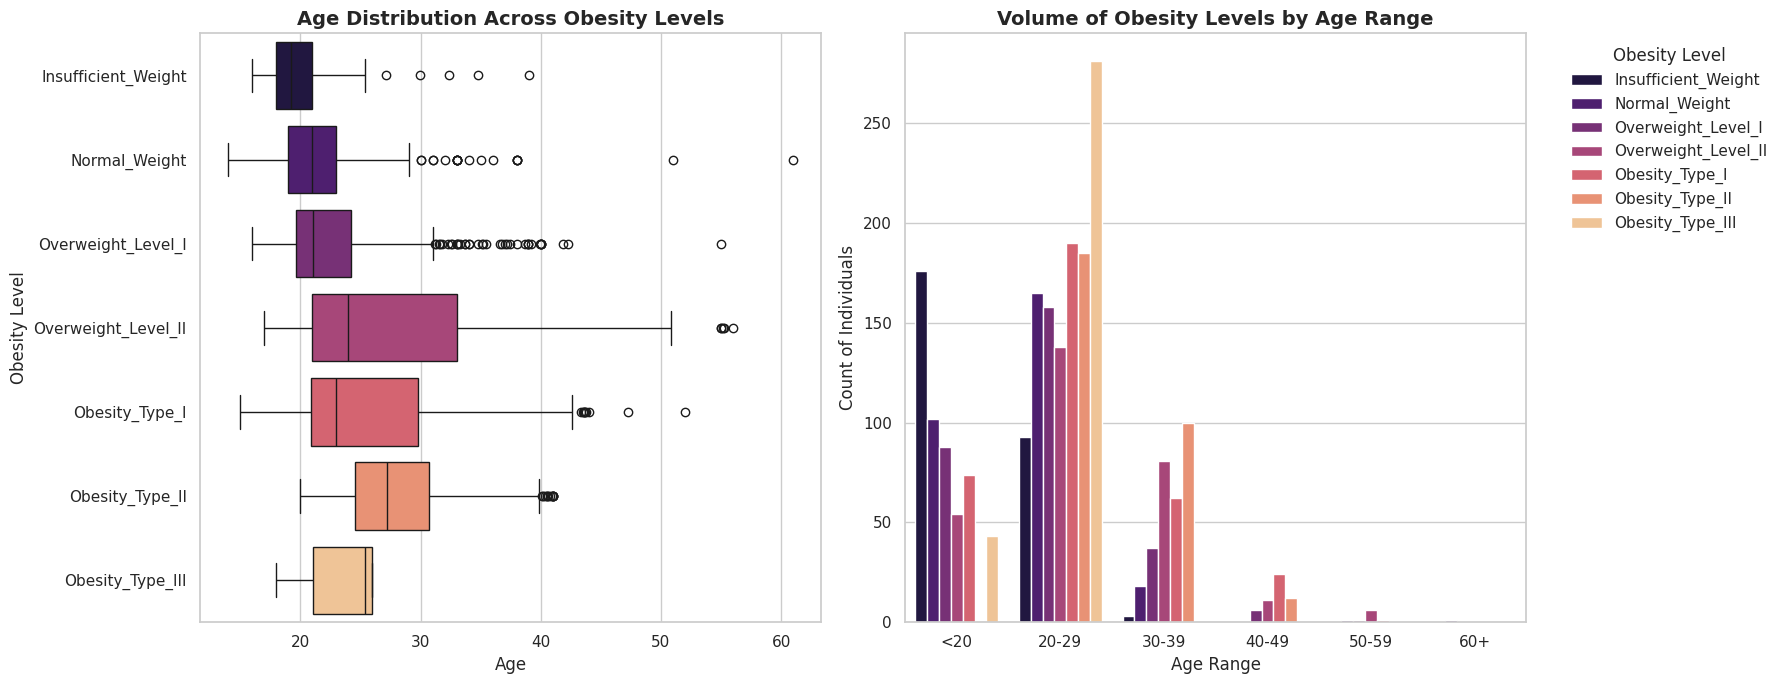

In [22]:
# 1. Feature Engineering: Create Age Bins (Age Ranges)
# Adjust these bins based on the min and max age in your specific dataset
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
df['Age_Range'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Define the logical order for the target variable (adjust strings if your dataset differs)
obesity_order = [
    'Insufficient_Weight', 
    'Normal_Weight', 
    'Overweight_Level_I', 
    'Overweight_Level_II', 
    'Obesity_Type_I', 
    'Obesity_Type_II', 
    'Obesity_Type_III'
]

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---------------------------------------------------------
# Plot 1: Boxplot (Continuous Age vs Categorical Obesity)
# ---------------------------------------------------------
sns.boxplot(
    data=df, 
    x='Age', 
    y='NObeyesdad', 
    order=obesity_order, 
    palette='magma', 
    ax=axes[0]
)
axes[0].set_title('Age Distribution Across Obesity Levels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Obesity Level', fontsize=12)

# ---------------------------------------------------------
# Plot 2: Countplot (Binned Age Range vs Categorical Obesity)
# ---------------------------------------------------------
sns.countplot(
    data=df, 
    x='Age_Range', 
    hue='NObeyesdad', 
    hue_order=obesity_order, 
    palette='magma', 
    ax=axes[1]
)
axes[1].set_title('Volume of Obesity Levels by Age Range', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Range', fontsize=12)
axes[1].set_ylabel('Count of Individuals', fontsize=12)

# Move the legend outside the plot for better readability
axes[1].legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Spearman Correlation (TDEE vs Obesity): 0.497


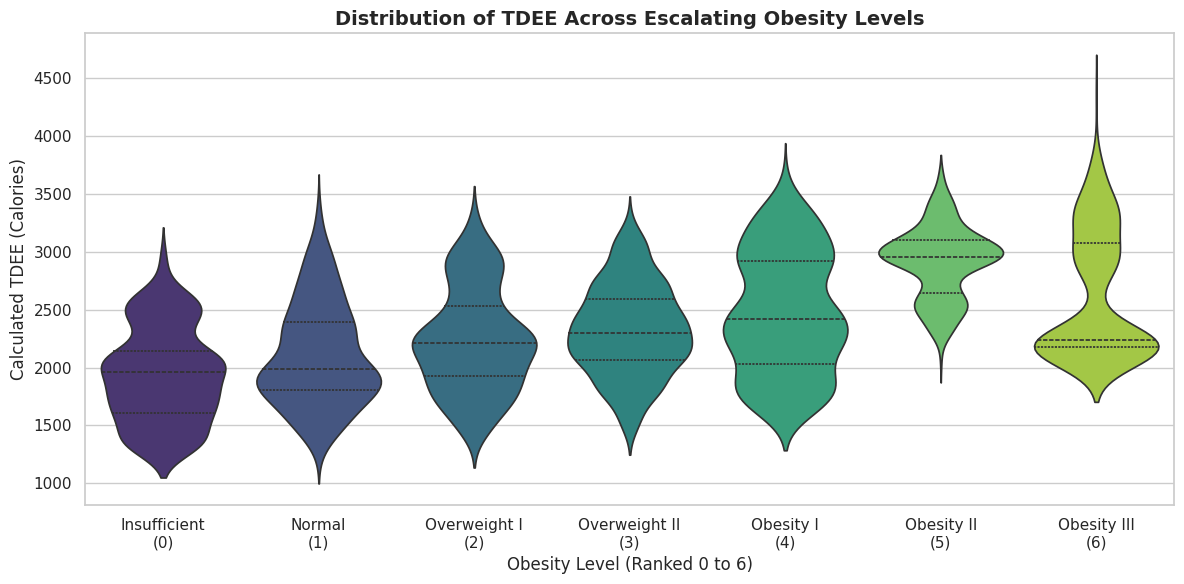

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ordinal Encoding: Map categorical levels to a logical numeric scale
obesity_mapping = {
    'Insufficient_Weight': 0, 
    'Normal_Weight': 1, 
    'Overweight_Level_I': 2, 
    'Overweight_Level_II': 3, 
    'Obesity_Type_I': 4, 
    'Obesity_Type_II': 5, 
    'Obesity_Type_III': 6
}

# Create a temporary numeric column for the calculation
df['Obesity_Numeric'] = df['NObeyesdad'].map(obesity_mapping)

# 2. Calculate Spearman Rank Correlation
# We use 'spearman' instead of 'pearson' because our target is an ordinal rank, not a true continuous measure.
correlation = df['TDEE'].corr(df['Obesity_Numeric'], method='spearman')

print(f"==================================================")
print(f"Spearman Correlation (TDEE vs Obesity): {correlation:.3f}")
print(f"==================================================")

# 3. Visualize the Relationship
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# A violin plot shows both the summary statistics (like a boxplot) and the density/shape of the distribution
sns.violinplot(
    data=df, 
    x='Obesity_Numeric', 
    y='TDEE', 
    hue='NObeyesdad',
    palette='viridis',
    inner='quartile', # Shows the quartiles inside the violins
    legend=False
)

# Formatting
plt.title('Distribution of TDEE Across Escalating Obesity Levels', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level (Ranked 0 to 6)', fontsize=12)
plt.ylabel('Calculated TDEE (Calories)', fontsize=12)

# Set readable x-tick labels
plt.xticks(
    ticks=range(7), 
    labels=[
        'Insufficient\n(0)', 'Normal\n(1)', 'Overweight I\n(2)', 
        'Overweight II\n(3)', 'Obesity I\n(4)', 'Obesity II\n(5)', 'Obesity III\n(6)'
    ]
)

plt.tight_layout()
plt.show()

# Clean up the temporary column if you don't need it for modeling
# df.drop(columns=['Obesity_Numeric'], inplace=True)

Spearman Correlation (Male TDEE vs Obesity): 0.531
Spearman Correlation (Female TDEE vs Obesity): 0.684


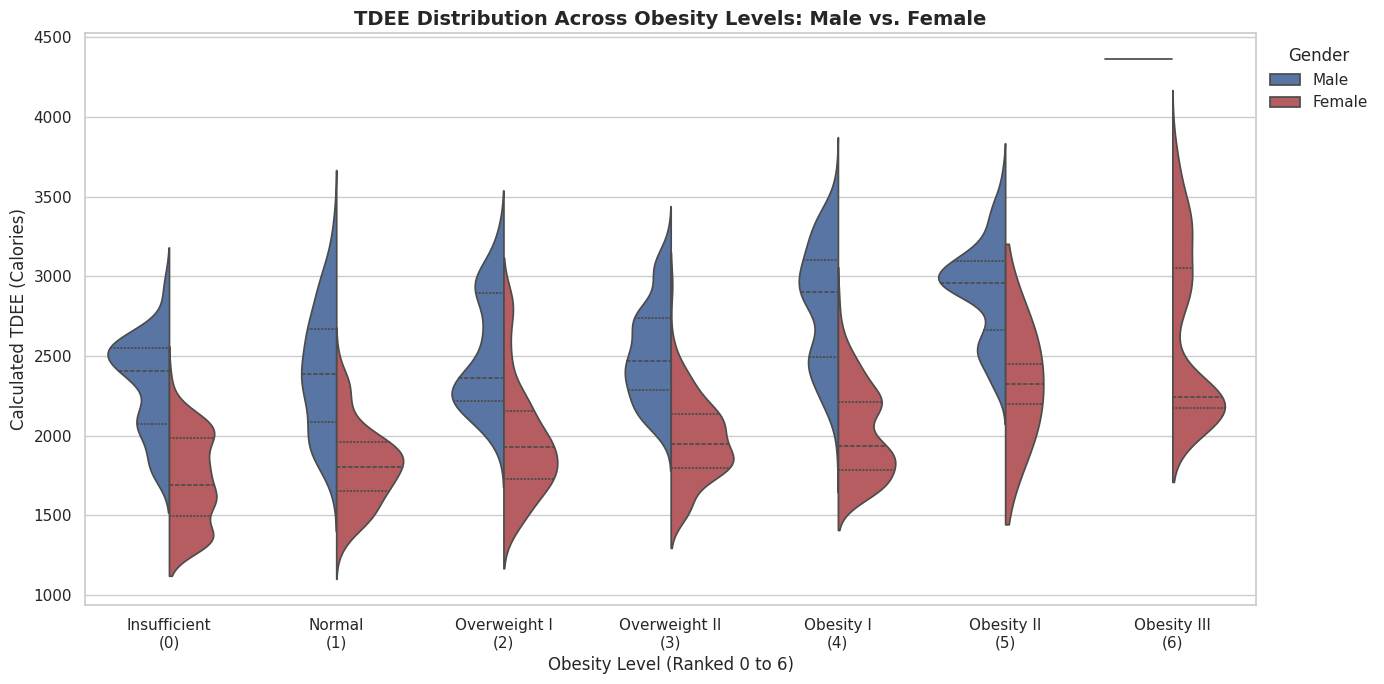

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure the ordinal encoding is present
obesity_mapping = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
# Only run this map if the column doesn't already exist from previous steps
if 'Obesity_Numeric' not in df.columns:
    df['Obesity_Numeric'] = df['NObeyesdad'].map(obesity_mapping)

# 2. Split the data and calculate separate Spearman correlations
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

corr_male = male_df['TDEE'].corr(male_df['Obesity_Numeric'], method='spearman')
corr_female = female_df['TDEE'].corr(female_df['Obesity_Numeric'], method='spearman')

print(f"==================================================")
print(f"Spearman Correlation (Male TDEE vs Obesity): {corr_male:.3f}")
print(f"Spearman Correlation (Female TDEE vs Obesity): {corr_female:.3f}")
print(f"==================================================")

# 3. Visualize with a Split Violin Plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# The 'split=True' argument puts Male on one side of the violin and Female on the other
sns.violinplot(
    data=df, 
    x='Obesity_Numeric', 
    y='TDEE', 
    hue='Gender', 
    split=True, 
    inner='quartile',
    palette={'Male': '#4C72B0', 'Female': '#C44E52'} 
)

plt.title('TDEE Distribution Across Obesity Levels: Male vs. Female', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level (Ranked 0 to 6)', fontsize=12)
plt.ylabel('Calculated TDEE (Calories)', fontsize=12)

plt.xticks(
    ticks=range(7), 
    labels=[
        'Insufficient\n(0)', 'Normal\n(1)', 'Overweight I\n(2)', 
        'Overweight II\n(3)', 'Obesity I\n(4)', 'Obesity II\n(5)', 'Obesity III\n(6)'
    ]
)

# Adjust legend location so it doesn't overlap data
plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Spearman Correlation (Male BMI vs Obesity): 0.980
Spearman Correlation (Female BMI vs Obesity): 0.977


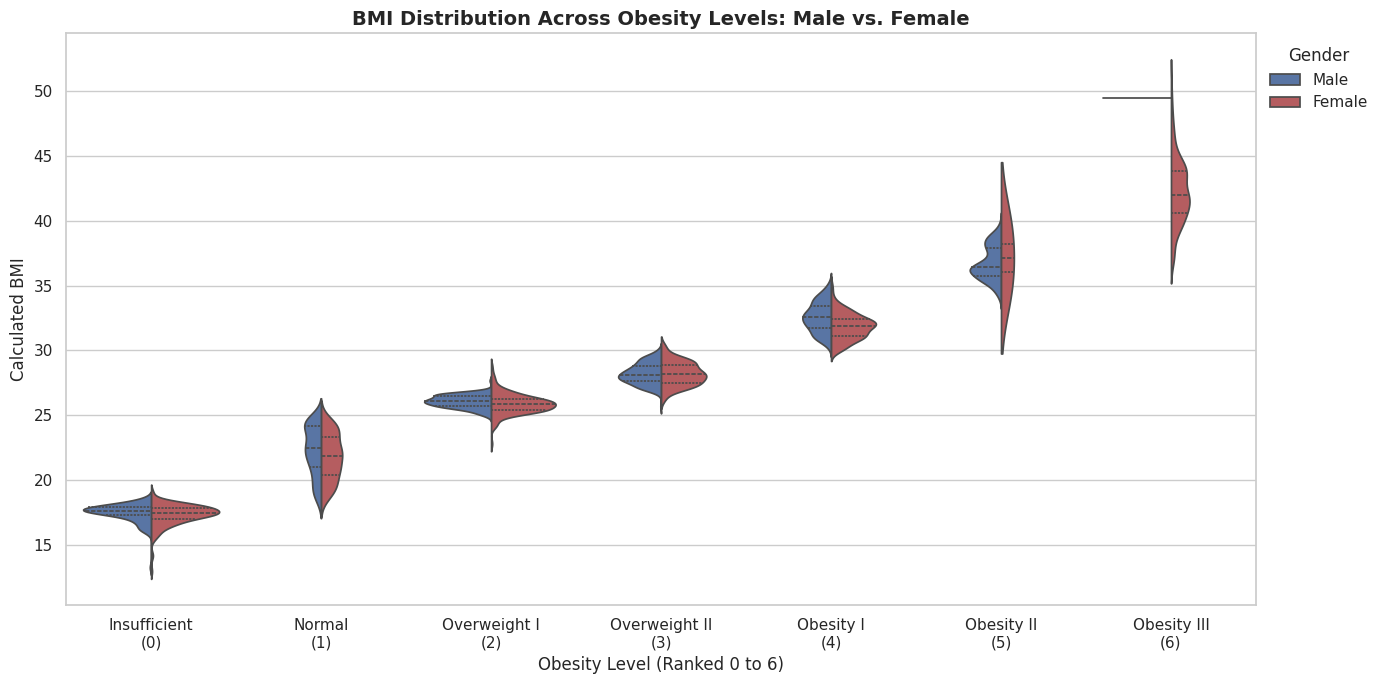

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure the ordinal encoding is present
obesity_mapping = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
if 'Obesity_Numeric' not in df.columns:
    df['Obesity_Numeric'] = df['NObeyesdad'].map(obesity_mapping)

# 2. Ensure BMI is calculated (from earlier feature engineering)
if 'BMI' not in df.columns:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# 3. Split the data and calculate separate Spearman correlations
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

corr_male_bmi = male_df['BMI'].corr(male_df['Obesity_Numeric'], method='spearman')
corr_female_bmi = female_df['BMI'].corr(female_df['Obesity_Numeric'], method='spearman')

print(f"==================================================")
print(f"Spearman Correlation (Male BMI vs Obesity): {corr_male_bmi:.3f}")
print(f"Spearman Correlation (Female BMI vs Obesity): {corr_female_bmi:.3f}")
print(f"==================================================")

# 4. Visualize with a Split Violin Plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=df, 
    x='Obesity_Numeric', 
    y='BMI', 
    hue='Gender', 
    split=True, 
    inner='quartile',
    palette={'Male': '#4C72B0', 'Female': '#C44E52'} 
)

plt.title('BMI Distribution Across Obesity Levels: Male vs. Female', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level (Ranked 0 to 6)', fontsize=12)
plt.ylabel('Calculated BMI', fontsize=12)

plt.xticks(
    ticks=range(7), 
    labels=[
        'Insufficient\n(0)', 'Normal\n(1)', 'Overweight I\n(2)', 
        'Overweight II\n(3)', 'Obesity I\n(4)', 'Obesity II\n(5)', 'Obesity III\n(6)'
    ]
)

plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Spearman Correlation (TDEE vs Obesity):              0.497
Spearman Correlation (Caloric Risk vs Obesity):      -0.005


/tmp/ipykernel_33527/2640775377.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_33527/2640775377.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


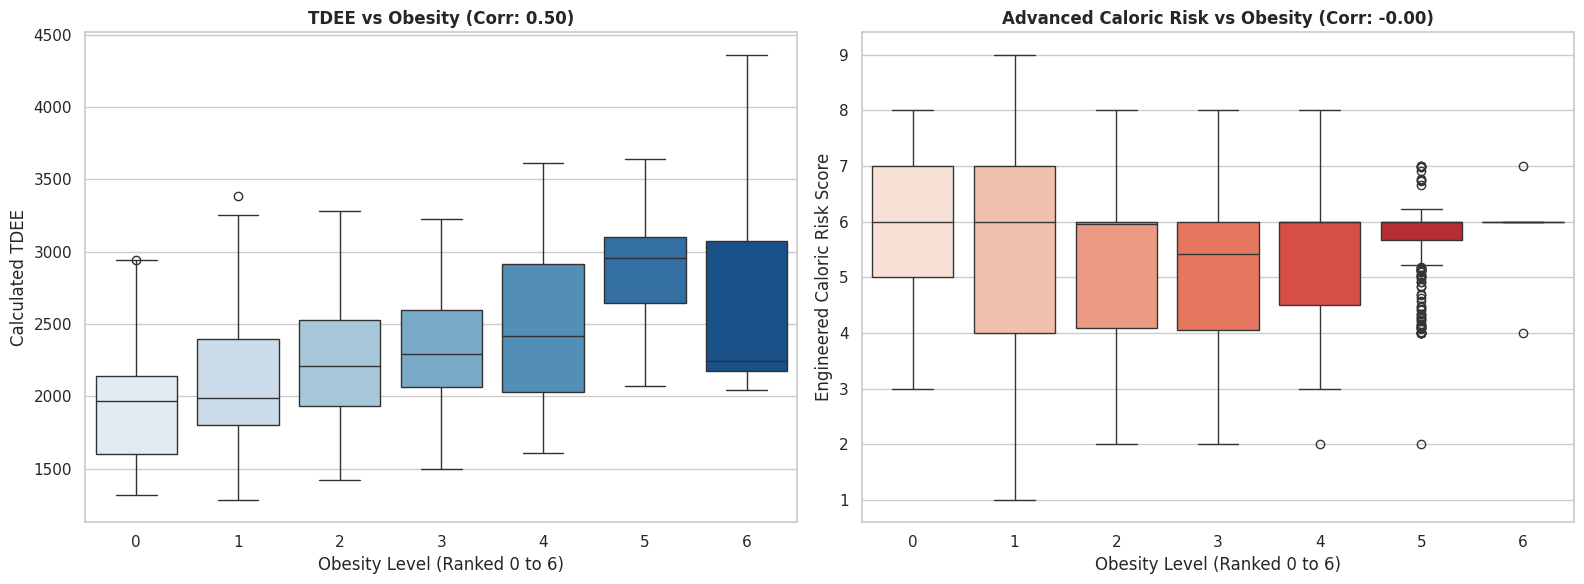

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Feature Engineering: Advanced Caloric Risk Score
# Map categorical behavioral features to numeric
caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
caec_score = df['CAEC'].map(caec_map).fillna(0)
favc_score = np.where(df['FAVC'] == 'yes', 2, 0)  # Give high-calorie foods a heavier weight of 2

# The Formula: (Main Meals + Snacking) + High Calorie Penalty
df['Advanced_Caloric_Risk'] = (df['NCP'] + caec_score) + favc_score

# Ensure Obesity is encoded numerically
obesity_mapping = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
if 'Obesity_Numeric' not in df.columns:
    df['Obesity_Numeric'] = df['NObeyesdad'].map(obesity_mapping)

# 2. Calculate Spearman Correlations
corr_tdee = df['TDEE'].corr(df['Obesity_Numeric'], method='spearman')
corr_caloric_risk = df['Advanced_Caloric_Risk'].corr(df['Obesity_Numeric'], method='spearman')

print(f"==========================================================")
print(f"Spearman Correlation (TDEE vs Obesity):              {corr_tdee:.3f}")
print(f"Spearman Correlation (Caloric Risk vs Obesity):      {corr_caloric_risk:.3f}")
print(f"==========================================================")

# 3. Visualize the Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot 1: TDEE vs Obesity
sns.boxplot(
    data=df, x='Obesity_Numeric', y='TDEE', 
    palette='Blues', ax=axes[0]
)
axes[0].set_title(f'TDEE vs Obesity (Corr: {corr_tdee:.2f})', fontweight='bold')
axes[0].set_xlabel('Obesity Level (Ranked 0 to 6)')
axes[0].set_ylabel('Calculated TDEE')

# Plot 2: Caloric Risk vs Obesity
sns.boxplot(
    data=df, x='Obesity_Numeric', y='Advanced_Caloric_Risk', 
    palette='Reds', ax=axes[1]
)
axes[1].set_title(f'Advanced Caloric Risk vs Obesity (Corr: {corr_caloric_risk:.2f})', fontweight='bold')
axes[1].set_xlabel('Obesity Level (Ranked 0 to 6)')
axes[1].set_ylabel('Engineered Caloric Risk Score')

plt.tight_layout()
plt.show()

Spearman Correlation (TDEE only):                    0.497
Spearman Correlation (Caloric Risk only):            -0.005
Spearman Correlation (COMBINED RISK INDEX):          0.387


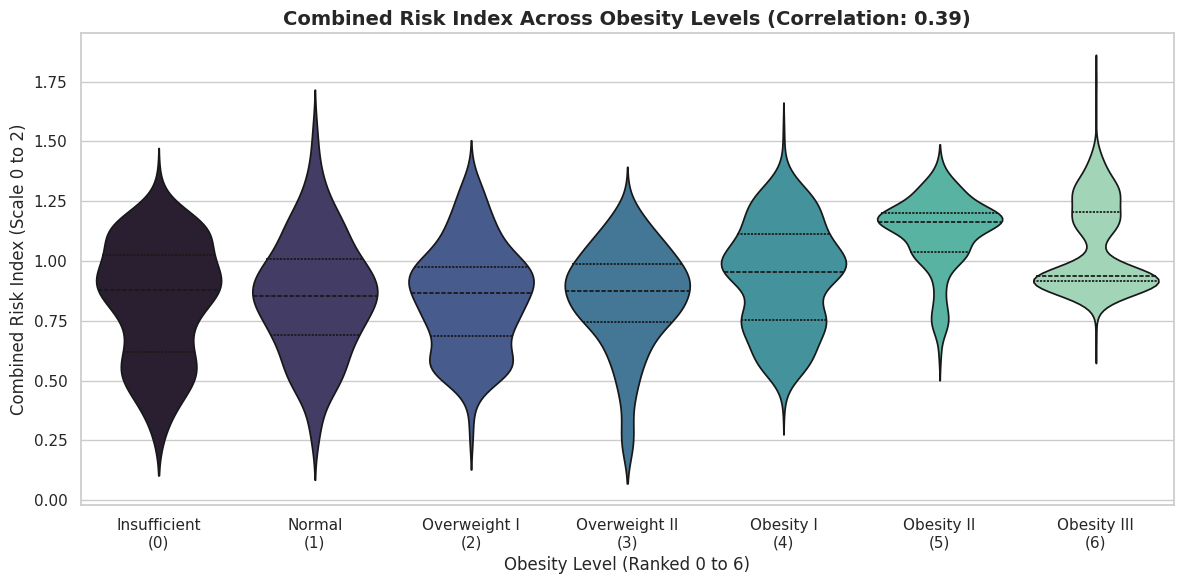

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Min-Max Scaling (Normalizing both features to a 0.0 - 1.0 scale)
tdee_min, tdee_max = df['TDEE'].min(), df['TDEE'].max()
df['Scaled_TDEE'] = (df['TDEE'] - tdee_min) / (tdee_max - tdee_min)

risk_min, risk_max = df['Advanced_Caloric_Risk'].min(), df['Advanced_Caloric_Risk'].max()
df['Scaled_Caloric_Risk'] = (df['Advanced_Caloric_Risk'] - risk_min) / (risk_max - risk_min)

# 2. Create the Combined Feature (Interaction Term)
# Adding the scaled variables creates a master index where 2.0 is the absolute highest risk
df['Combined_Risk_Index'] = df['Scaled_TDEE'] + df['Scaled_Caloric_Risk']

# 3. Calculate all correlations for comparison
corr_tdee = df['TDEE'].corr(df['Obesity_Numeric'], method='spearman')
corr_risk = df['Advanced_Caloric_Risk'].corr(df['Obesity_Numeric'], method='spearman')
corr_combined = df['Combined_Risk_Index'].corr(df['Obesity_Numeric'], method='spearman')

print(f"==========================================================")
print(f"Spearman Correlation (TDEE only):                    {corr_tdee:.3f}")
print(f"Spearman Correlation (Caloric Risk only):            {corr_risk:.3f}")
print(f"Spearman Correlation (COMBINED RISK INDEX):          {corr_combined:.3f}")
print(f"==========================================================")

# 4. Visualize the Combined Feature
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=df, 
    x='Obesity_Numeric', 
    y='Combined_Risk_Index', 
    hue='NObeyesdad',
    palette='mako',
    inner='quartile',
    legend=False
)

plt.title(f'Combined Risk Index Across Obesity Levels (Correlation: {corr_combined:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level (Ranked 0 to 6)', fontsize=12)
plt.ylabel('Combined Risk Index (Scale 0 to 2)', fontsize=12)

plt.xticks(
    ticks=range(7), 
    labels=[
        'Insufficient\n(0)', 'Normal\n(1)', 'Overweight I\n(2)', 
        'Overweight II\n(3)', 'Obesity I\n(4)', 'Obesity II\n(5)', 'Obesity III\n(6)'
    ]
)

plt.tight_layout()
plt.show()

Spearman Correlation (Male Combined Risk vs Obesity):   0.332
Spearman Correlation (Female Combined Risk vs Obesity): 0.503


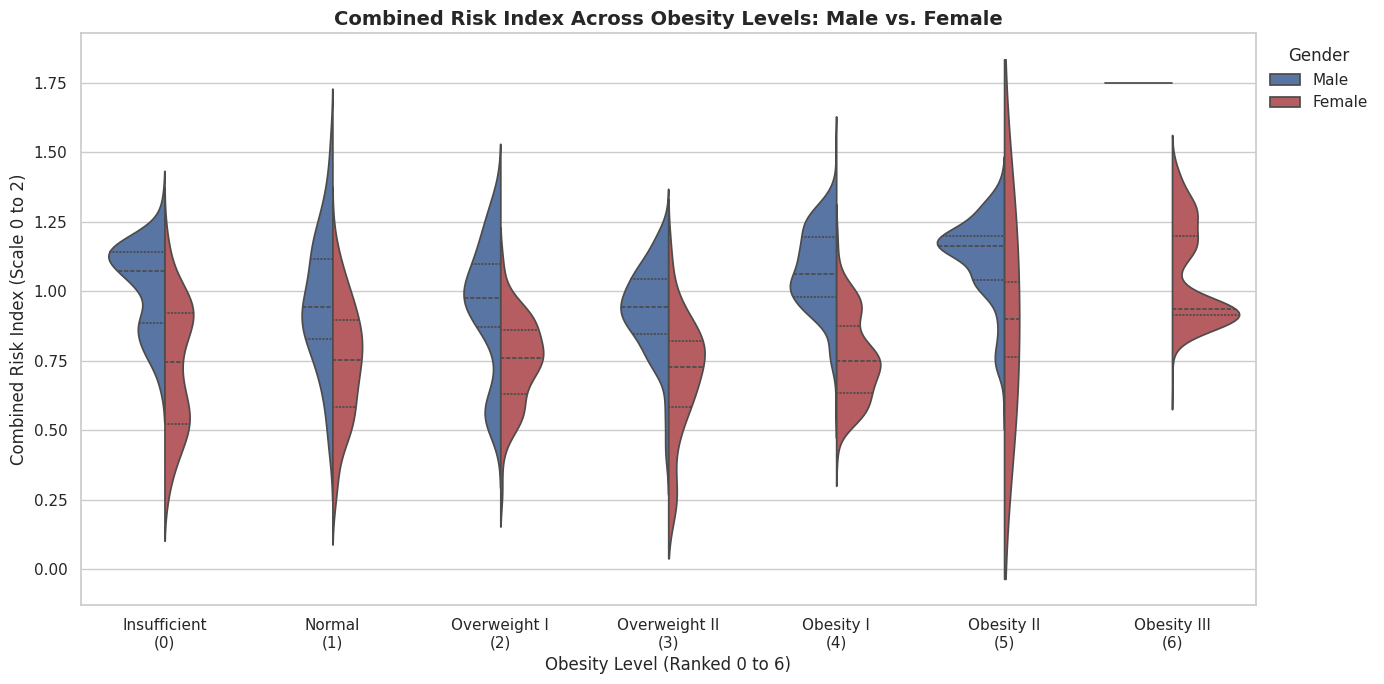

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Split the data and calculate separate Spearman correlations
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

# Calculate correlation for the Combined Risk Index against Obesity
corr_male_risk = male_df['Combined_Risk_Index'].corr(male_df['Obesity_Numeric'], method='spearman')
corr_female_risk = female_df['Combined_Risk_Index'].corr(female_df['Obesity_Numeric'], method='spearman')

print(f"==========================================================")
print(f"Spearman Correlation (Male Combined Risk vs Obesity):   {corr_male_risk:.3f}")
print(f"Spearman Correlation (Female Combined Risk vs Obesity): {corr_female_risk:.3f}")
print(f"==========================================================")

# 2. Visualize with a Split Violin Plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create the split violin plot
sns.violinplot(
    data=df, 
    x='Obesity_Numeric', 
    y='Combined_Risk_Index', 
    hue='Gender', 
    split=True, 
    inner='quartile',
    palette={'Male': '#4C72B0', 'Female': '#C44E52'} 
)

# Formatting
plt.title('Combined Risk Index Across Obesity Levels: Male vs. Female', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level (Ranked 0 to 6)', fontsize=12)
plt.ylabel('Combined Risk Index (Scale 0 to 2)', fontsize=12)

plt.xticks(
    ticks=range(7), 
    labels=[
        'Insufficient\n(0)', 'Normal\n(1)', 'Overweight I\n(2)', 
        'Overweight II\n(3)', 'Obesity I\n(4)', 'Obesity II\n(5)', 'Obesity III\n(6)'
    ]
)

plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()